# Análisis de personal Yape - Abril 2026

Notebook limpio y parametrizable para analizar:

- Personal activo.
- Ingresos del mes.
- Salidas del mes.
- Distribución por ciudad.
- Nuevos activos que sí/no realizaron afiliaciones.
- Rotación del mes.
- Crecimiento neto de afiliadores, excluyendo gestores.

> Ajusta los nombres de archivo, mes, año y columnas si cambian en tus Excels.

In [1]:
import pandas as pd
from pathlib import Path

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

## 1. Parámetros

In [2]:
# Archivos de entrada
ARCHIVO_PERSONAL = Path("PERSONAL_YAPE.xlsx")
ARCHIVO_PRODUCCION = Path("CONSOLIDADO_270426.xlsx")

# Periodo de análisis
ANIO = 2026
MES = 4

FECHA_INICIO = pd.Timestamp(year=ANIO, month=MES, day=1)
FECHA_FIN = FECHA_INICIO + pd.offsets.MonthEnd(0)

print(f"Periodo de análisis: {FECHA_INICIO.date()} al {FECHA_FIN.date()}")

Periodo de análisis: 2026-04-01 al 2026-04-30


## 2. Funciones auxiliares

In [3]:
def cargar_personal(ruta: Path) -> pd.DataFrame:
    """Carga y normaliza la base de personal."""
    df = pd.read_excel(ruta)

    # Normalizar nombres de columnas
    df.columns = df.columns.str.strip()

    # Fechas
    columnas_fecha = ["FECHA DE INGRESO", "FECHA DE SALIDA"]
    for col in columnas_fecha:
        if col in df.columns:
            df[col] = pd.to_datetime(df[col], errors="coerce")

    # Texto
    columnas_texto = ["ESTADO (ACTIVO/INACTIVO)", "CIUDAD", "CELULAR", "NOMBRE"]
    for col in columnas_texto:
        if col in df.columns:
            df[col] = df[col].astype(str).str.strip()

    # Estado en mayúsculas
    if "ESTADO (ACTIVO/INACTIVO)" in df.columns:
        df["ESTADO (ACTIVO/INACTIVO)"] = df["ESTADO (ACTIVO/INACTIVO)"].str.upper()

    # Celular como texto limpio
    if "CELULAR" in df.columns:
        df["CELULAR"] = df["CELULAR"].str.replace(r"\.0$", "", regex=True)

    return df


def cargar_produccion(ruta: Path) -> pd.DataFrame:
    """Carga y normaliza la base de producción/afiliaciones."""
    df = pd.read_excel(ruta, dtype=str)
    df.columns = df.columns.str.strip()

    if "ID EJECUTIVO" in df.columns:
        df["ID EJECUTIVO"] = (
            df["ID EJECUTIVO"]
            .astype(str)
            .str.strip()
            .str.replace(r"\.0$", "", regex=True)
        )

    return df


def filtrar_rango_fecha(df: pd.DataFrame, columna_fecha: str, inicio, fin) -> pd.DataFrame:
    """Filtra filas cuya fecha esté dentro del rango indicado."""
    return df[df[columna_fecha].between(inicio, fin, inclusive="both")].copy()


def mostrar_resumen(titulo: str, datos: dict) -> None:
    """Imprime un resumen simple y ordenado."""
    print("=" * 70)
    print(titulo)
    print("=" * 70)
    for clave, valor in datos.items():
        print(f"{clave}: {valor}")
    print("=" * 70)

## 3. Carga de datos

In [4]:
df_personal = cargar_personal(ARCHIVO_PERSONAL)
df_prod = cargar_produccion(ARCHIVO_PRODUCCION)

print("Columnas en PERSONAL:")
print(df_personal.columns.tolist())

print("\nColumnas en PRODUCCIÓN:")
print(df_prod.columns.tolist())

Columnas en PERSONAL:
['EMPRESA', 'CODIGO', 'C.I.', 'NOMBRE', 'APELLIDO PATERNO', 'APELLIDO MATERNO', 'NOMBRES', 'FECHA DE INGRESO', 'CARGO', 'CIUDAD', 'SUPERVISOR', 'ESTADO (ACTIVO/INACTIVO)', 'CELULAR', 'FECHA DE SALIDA', 'N DE CUENTA', 'BANCO', 'CAMPAÑA', 'RECLUTADOR', 'FECHA DE NACIMIENTO', 'CORREO', 'DOMICILIO', 'DISPONIBILIDAD', 'MOTIVO DE SALIDA']

Columnas en PRODUCCIÓN:
['fecha', 'cod_comercio', 'cod_afiliador', 'estado_observacion', 'nuevo_bautizo', 'NOMBRE_YAPE', 'SUPERVISOR', 'CIUDAD_PERSONAL', 'CIUDAD_FORMULARIO', 'CORREO', 'ID UNICO', 'Submission Date', 'ID EJECUTIVO', 'NUMERO DE CUENTA', 'BANCO', 'FECHA_INGRESO', 'FECHA_SALIDA', 'RECLUTADOR', 'DISTRITO', 'ZONA', 'CATEGORIA', 'RUBRO', 'ACTIVIDAD', 'GEOLOCALIZACION']


## 4. Filtros principales

In [5]:
COL_ESTADO = "ESTADO (ACTIVO/INACTIVO)"
COL_INGRESO = "FECHA DE INGRESO"
COL_SALIDA = "FECHA DE SALIDA"
COL_CELULAR = "CELULAR"
COL_ID_EJECUTIVO = "ID EJECUTIVO"

df_activos = df_personal[df_personal[COL_ESTADO] == "ACTIVO"].copy()
df_ingresos_mes = filtrar_rango_fecha(
    df_personal[df_personal[COL_ESTADO] == "ACTIVO"],
    COL_INGRESO,
    FECHA_INICIO,
    FECHA_FIN
)

df_salidas_mes = filtrar_rango_fecha(
    df_personal[df_personal[COL_ESTADO] == "INACTIVO"],
    COL_SALIDA,
    FECHA_INICIO,
    FECHA_FIN
)

mostrar_resumen(
    f"Resumen general - {FECHA_INICIO.strftime('%B %Y')}",
    {
        "Personas activas": len(df_activos),
        "Ingresos del mes": len(df_ingresos_mes),
        "Salidas del mes": len(df_salidas_mes),
    }
)

Resumen general - April 2026
Personas activas: 205
Ingresos del mes: 66
Salidas del mes: 3


## 5. Distribución de activos por ciudad

In [6]:
distribucion_ciudad = (
    df_activos["CIUDAD"]
    .replace({"nan": "SIN CIUDAD", "": "SIN CIUDAD"})
    .value_counts()
    .rename_axis("CIUDAD")
    .reset_index(name="CANTIDAD")
)

distribucion_ciudad

,CIUDAD,CANTIDAD
0,LA PAZ,107
1,SANTA CRUZ,59
2,COCHABAMBA,39


## 6. Nuevos activos del mes con y sin afiliaciones

In [7]:
# Nuevos que ingresaron en el mes y siguen activos
nuevos_activos = df_ingresos_mes[df_ingresos_mes[COL_ESTADO] == "ACTIVO"].copy()

# IDs de ejecutivos con producción
ids_con_produccion = set(df_prod[COL_ID_EJECUTIVO].dropna().astype(str).str.strip())

# Marcar productividad
nuevos_activos["TIENE_AFILIACIONES"] = nuevos_activos[COL_CELULAR].isin(ids_con_produccion)

nuevos_con_afiliaciones = nuevos_activos[nuevos_activos["TIENE_AFILIACIONES"]].copy()
nuevos_sin_afiliaciones = nuevos_activos[~nuevos_activos["TIENE_AFILIACIONES"]].copy()

mostrar_resumen(
    "Productividad de nuevos activos",
    {
        "Nuevos activos del mes": len(nuevos_activos),
        "Nuevos activos con afiliaciones": nuevos_con_afiliaciones[COL_CELULAR].nunique(),
        "Nuevos activos sin afiliaciones": nuevos_sin_afiliaciones[COL_CELULAR].nunique(),
    }
)

Productividad de nuevos activos
Nuevos activos del mes: 66
Nuevos activos con afiliaciones: 54
Nuevos activos sin afiliaciones: 10


In [8]:
# Detalle de nuevos activos con afiliaciones
columnas_detalle = [col for col in ["NOMBRE", "CELULAR", "CIUDAD", "FECHA DE INGRESO"] if col in nuevos_con_afiliaciones.columns]
nuevos_con_afiliaciones[columnas_detalle]

,NOMBRE,CELULAR,CIUDAD,FECHA DE INGRESO
340,ROGER ALVARO SANCHEZ MELGAREJO,65321283,COCHABAMBA,2026-04-06
357,RODRIGO HIDALGO VALENZUELA,76937359,COCHABAMBA,2026-04-08
375,GEORGINA MAYDA MATIAS ARANIBAR,69577626,SANTA CRUZ,2026-04-06
376,IVAN DIAZ GARCIA,75547090,SANTA CRUZ,2026-04-06
377,RODRIGO AYALA ALIS,78027958,SANTA CRUZ,2026-04-06
378,SEBASTIAN MARTINEZ ROCA,76081536,SANTA CRUZ,2026-04-06
379,CARLA JAHEL DE LA RIVA PEREZ,77056611,SANTA CRUZ,2026-04-06
380,JANKO FARID SALAZAR FLORES,61550579,SANTA CRUZ,2026-04-06
381,DEYSI ALCON,76358681,SANTA CRUZ,2026-04-06
382,YANELY GARRIDO SUAREZ,75074848,SANTA CRUZ,2026-04-07


In [9]:
# Detalle de nuevos activos sin afiliaciones
columnas_detalle = [col for col in ["NOMBRE", "CELULAR", "CIUDAD", "FECHA DE INGRESO"] if col in nuevos_sin_afiliaciones.columns]
nuevos_sin_afiliaciones[columnas_detalle]

,NOMBRE,CELULAR,CIUDAD,FECHA DE INGRESO
356,CBBA PROYECTO GESTORES,77042024,COCHABAMBA,2026-04-06
444,HUASCAR HIPOLITO DURAN RAMOS,78867629,LA PAZ,2026-04-01
458,LPZ PROYECTO GESTORES,77042024,LA PAZ,2026-04-06
459,VLADIMIR FRANK MAMANI FLORES,63158676,LA PAZ,2026-04-07
461,SCZ PROYECTO GESTORES,77042024,SANTA CRUZ,2026-04-06
481,ASHEM ENZO DIAZ ANIBARRO,72077573,LA PAZ,2026-04-07
484,FABIAN SAUL ARTAS FLORES,62409528,LA PAZ,2026-04-07
485,TANIA GUACHALLA TINTA,71285076,LA PAZ,2026-04-07
487,LEONEL SANDOVAL MARTINEZ,63200938,LA PAZ,2026-04-10
496,RODRIGO RAFAEL CALLAU CHOQUE,77767980,LA PAZ,2026-04-15


## 7. Rotación del mes

In [10]:
# Personas que tuvieron movimiento en el mes: ingresos o salidas
df_movimiento_mes = (
    pd.concat([df_ingresos_mes, df_salidas_mes], ignore_index=True)
    .drop_duplicates()
)

activos_mes = (df_movimiento_mes[COL_ESTADO] == "ACTIVO").sum()
inactivos_mes = (df_movimiento_mes[COL_ESTADO] == "INACTIVO").sum()
total_movimiento_mes = activos_mes + inactivos_mes

rotacion_mes = (
    inactivos_mes / total_movimiento_mes * 100
    if total_movimiento_mes > 0
    else 0
)

mostrar_resumen(
    "Rotación del mes",
    {
        "Activos con movimiento en el mes": activos_mes,
        "Inactivos con movimiento en el mes": inactivos_mes,
        "Total con movimiento en el mes": total_movimiento_mes,
        "Rotación del mes": f"{rotacion_mes:.2f}%",
    }
)

Rotación del mes
Activos con movimiento en el mes: 66
Inactivos con movimiento en el mes: 3
Total con movimiento en el mes: 69
Rotación del mes: 4.35%


## 8. Crecimiento neto de afiliadores, excluyendo gestores

Esta sección asume que existe una columna que identifica el cargo o rol, por ejemplo `CARGO`, `PUESTO`, `ROL` o similar.

Edita `COL_ROL` según el nombre real de tu archivo.

In [11]:
# Cambia esta columna si en tu Excel tiene otro nombre:
COL_ROL = "CARGO"

if COL_ROL in df_personal.columns:
    # Excluir gestores y quedarnos solo con afiliadores u otros roles no gestores
    personal_sin_gestores = df_personal[
        ~df_personal[COL_ROL].astype(str).str.upper().str.contains("GESTOR", na=False)
    ].copy()

    ingresos_afiliadores_mes = filtrar_rango_fecha(personal_sin_gestores, COL_INGRESO, FECHA_INICIO, FECHA_FIN)
    salidas_afiliadores_mes = filtrar_rango_fecha(personal_sin_gestores, COL_SALIDA, FECHA_INICIO, FECHA_FIN)

    crecimiento_neto_afiliadores = len(ingresos_afiliadores_mes) - len(salidas_afiliadores_mes)

    base_activos_afiliadores = personal_sin_gestores[
        personal_sin_gestores[COL_ESTADO] == "ACTIVO"
    ]

    porcentaje_crecimiento_afiliadores = (
        crecimiento_neto_afiliadores / len(base_activos_afiliadores) * 100
        if len(base_activos_afiliadores) > 0
        else 0
    )

    mostrar_resumen(
        "Crecimiento de afiliadores, excluyendo gestores",
        {
            "Ingresos afiliadores del mes": len(ingresos_afiliadores_mes),
            "Salidas afiliadores del mes": len(salidas_afiliadores_mes),
            "Crecimiento neto afiliadores": crecimiento_neto_afiliadores,
            "Base activa afiliadores": len(base_activos_afiliadores),
            "Porcentaje de crecimiento": f"{porcentaje_crecimiento_afiliadores:.2f}%",
        }
    )

else:
    print(f"No encontré la columna '{COL_ROL}'.")
    print("Columnas disponibles:")
    print(df_personal.columns.tolist())
    print("\nActualiza COL_ROL con el nombre correcto de la columna de cargo/rol.")

Crecimiento de afiliadores, excluyendo gestores
Ingresos afiliadores del mes: 67
Salidas afiliadores del mes: 19
Crecimiento neto afiliadores: 48
Base activa afiliadores: 205
Porcentaje de crecimiento: 23.41%


In [12]:
# =========================================================
# CRUCE PERSONAL VS PRODUCCIÓN
# =========================================================

COL_CARGO = "CARGO"
COL_CELULAR = "CELULAR"
COL_ID_EJECUTIVO = "ID EJECUTIVO"

# Normalizar claves
df_personal[COL_CARGO] = df_personal[COL_CARGO].astype(str).str.strip().str.upper()
df_personal[COL_CELULAR] = df_personal[COL_CELULAR].astype(str).str.strip()
df_prod[COL_ID_EJECUTIVO] = df_prod[COL_ID_EJECUTIVO].astype(str).str.strip()

# IDs únicos que tuvieron producción
ids_con_produccion = set(df_prod[COL_ID_EJECUTIVO].dropna().unique())

# Crear columna de cruce
df_personal["TIENE_PRODUCCION"] = df_personal[COL_CELULAR].isin(ids_con_produccion)

# Crear columna final: afiliador realmente activo
df_personal["AFILIADOR_REALMENTE_ACTIVO"] = (
    (df_personal[COL_CARGO] == "AFILIADOR") &
    (df_personal["TIENE_PRODUCCION"])
)

# Versión texto para leer más fácil
df_personal["ESTADO_PRODUCTIVO"] = df_personal["AFILIADOR_REALMENTE_ACTIVO"].map({
    True: "AFILIADOR CON PRODUCCIÓN",
    False: "SIN PRODUCCIÓN / NO AFILIADOR"
})

# Resumen
mostrar_resumen(
    "Cruce personal vs producción",
    {
        "Total personal": len(df_personal),
        "Afiliadores con producción": df_personal["AFILIADOR_REALMENTE_ACTIVO"].sum(),
        "Afiliadores sin producción": (
            (df_personal[COL_CARGO] == "AFILIADOR") &
            (~df_personal["TIENE_PRODUCCION"])
        ).sum(),
        "No afiliadores": (df_personal[COL_CARGO] != "AFILIADOR").sum(),
    }
)

Cruce personal vs producción
Total personal: 961
Afiliadores con producción: 253
Afiliadores sin producción: 666
No afiliadores: 42


In [13]:
len(df_prod[COL_ID_EJECUTIVO].unique())

173

In [14]:
# =========================================================
# VALIDAR IDs CON PRODUCCIÓN
# SOLO AFILIADORES ACTIVOS
# =========================================================

COL_CARGO = "CARGO"
COL_CELULAR = "CELULAR"
COL_ID_EJECUTIVO = "ID EJECUTIVO"

# Normalizar columnas
df_prod[COL_ID_EJECUTIVO] = (
    df_prod[COL_ID_EJECUTIVO]
    .astype(str)
    .str.strip()
)

df_personal[COL_CELULAR] = (
    df_personal[COL_CELULAR]
    .astype(str)
    .str.strip()
)

df_personal[COL_CARGO] = (
    df_personal[COL_CARGO]
    .astype(str)
    .str.strip()
    .str.upper()
)

df_personal[COL_ESTADO] = (
    df_personal[COL_ESTADO]
    .astype(str)
    .str.strip()
    .str.upper()
)

# ---------------------------------------------------------
# IDs únicos con producción
# ---------------------------------------------------------
ids_produccion = (
    df_prod[COL_ID_EJECUTIVO]
    .dropna()
    .unique()
)

# ---------------------------------------------------------
# Filtrar SOLO afiliadores activos
# ---------------------------------------------------------
df_afiliadores_activos = df_personal[
    (df_personal[COL_CARGO] == "AFILIADOR") &
    (df_personal[COL_ESTADO] == "ACTIVO")
].copy()

# ---------------------------------------------------------
# Cruce producción vs afiliadores activos
# ---------------------------------------------------------
df_afiliadores_productivos = df_afiliadores_activos[
    df_afiliadores_activos[COL_CELULAR].isin(ids_produccion)
].copy()

# ---------------------------------------------------------
# Eliminar duplicados por celular
# (muy importante)
# ---------------------------------------------------------
df_afiliadores_productivos = (
    df_afiliadores_productivos
    .drop_duplicates(subset=[COL_CELULAR])
)

# ---------------------------------------------------------
# Resultados
# ---------------------------------------------------------
print("=" * 70)
print("AFILIADORES ACTIVOS CON PRODUCCIÓN")
print("=" * 70)

print(
    "Cantidad afiliadores activos con producción:",
    len(df_afiliadores_productivos)
)

print("=" * 70)

# Ver detalle
df_afiliadores_productivos[
    [
        "NOMBRE",
        COL_CELULAR,
        COL_CARGO,
        COL_ESTADO,
        COL_INGRESO
    ]
]

AFILIADORES ACTIVOS CON PRODUCCIÓN
Cantidad afiliadores activos con producción: 171


,NOMBRE,CELULAR,CARGO,ESTADO (ACTIVO/INACTIVO),FECHA DE INGRESO
339,MARISOL MAMANI MAMANI,68090705,AFILIADOR,ACTIVO,2026-03-01
340,ROGER ALVARO SANCHEZ MELGAREJO,65321283,AFILIADOR,ACTIVO,2026-04-06
346,ANDRES ARTURO COLLAO TERAN,76233082,AFILIADOR,ACTIVO,2025-10-15
347,ROSSIO MARIBEL SULLCATA QUISPE,76284530,AFILIADOR,ACTIVO,2025-11-26
350,JHOSELIN ROCA GARCIA,78311831,AFILIADOR,ACTIVO,2025-05-27
...,...,...,...,...,...
743,YOCELIN CARBALLO ROJAS,72740281,AFILIADOR,ACTIVO,2026-03-04
744,ELVER CHOQUE,63540724,AFILIADOR,ACTIVO,2025-07-20
745,XIMENA GUTIERREZ ARGIRO,74617757,AFILIADOR,ACTIVO,2025-11-07
746,BERENISE MERUBIA CARDOZO,69037293,AFILIADOR,ACTIVO,2025-11-01


In [15]:
# =========================================================
# AFILIADORES ESPERADOS VS AFILIADORES CON PRODUCCIÓN
# Con corte según fecha de producción
# =========================================================

COL_CARGO = "CARGO"
COL_CELULAR = "CELULAR"
COL_ID_EJECUTIVO = "ID EJECUTIVO"

FECHA_CORTE_PRODUCCION = pd.to_datetime("2026-04-27")

# ---------------------------------------------------------
# Normalizar columnas
# ---------------------------------------------------------
df_personal[COL_CARGO] = df_personal[COL_CARGO].astype(str).str.strip().str.upper()
df_personal[COL_ESTADO] = df_personal[COL_ESTADO].astype(str).str.strip().str.upper()
df_personal[COL_CELULAR] = df_personal[COL_CELULAR].astype(str).str.strip()
df_personal[COL_INGRESO] = pd.to_datetime(df_personal[COL_INGRESO], errors="coerce")

df_prod[COL_ID_EJECUTIVO] = df_prod[COL_ID_EJECUTIVO].astype(str).str.strip()

# ---------------------------------------------------------
# IDs únicos que sí tuvieron producción hasta la fecha corte
# ---------------------------------------------------------
ids_con_produccion = set(
    df_prod[COL_ID_EJECUTIVO]
    .dropna()
    .unique()
)

# ---------------------------------------------------------
# Afiliadores que ingresaron en el mes,
# pero solo hasta la fecha de corte de producción
# ---------------------------------------------------------
df_afiliadores_ingreso_mes = filtrar_rango_fecha(
    df_personal[df_personal[COL_CARGO] == "AFILIADOR"],
    COL_INGRESO,
    FECHA_INICIO,
    FECHA_CORTE_PRODUCCION
)

# ---------------------------------------------------------
# Afiliadores activos según estado,
# excluyendo ingresos posteriores a la fecha de corte
# ---------------------------------------------------------
df_afiliadores_estado_activo = df_personal[
    (df_personal[COL_CARGO] == "AFILIADOR") &
    (df_personal[COL_ESTADO] == "ACTIVO") &
    (df_personal[COL_INGRESO] <= FECHA_CORTE_PRODUCCION)
].copy()

# ---------------------------------------------------------
# Base esperada:
# ingresaron hasta el corte O están activos hasta el corte
# ---------------------------------------------------------
df_afiliadores_esperados = pd.concat(
    [
        df_afiliadores_ingreso_mes,
        df_afiliadores_estado_activo
    ],
    ignore_index=True
).drop_duplicates(subset=[COL_CELULAR])

# ---------------------------------------------------------
# Marcar si hicieron producción
# ---------------------------------------------------------
df_afiliadores_esperados["HIZO_AFILIACIONES"] = (
    df_afiliadores_esperados[COL_CELULAR].isin(ids_con_produccion)
)

df_afiliadores_esperados["ESTADO_PRODUCCION"] = df_afiliadores_esperados[
    "HIZO_AFILIACIONES"
].map({
    True: "CON PRODUCCIÓN",
    False: "SIN PRODUCCIÓN"
})

# ---------------------------------------------------------
# Afiliadores esperados que NO produjeron
# ---------------------------------------------------------
df_afiliadores_sin_produccion = df_afiliadores_esperados[
    ~df_afiliadores_esperados["HIZO_AFILIACIONES"]
].copy()

# ---------------------------------------------------------
# Indicadores
# ---------------------------------------------------------
total_esperados = len(df_afiliadores_esperados)
total_con_produccion = df_afiliadores_esperados["HIZO_AFILIACIONES"].sum()
total_sin_produccion = len(df_afiliadores_sin_produccion)

porcentaje_sin_produccion = (
    total_sin_produccion / total_esperados * 100
    if total_esperados > 0 else 0
)

porcentaje_con_produccion = (
    total_con_produccion / total_esperados * 100
    if total_esperados > 0 else 0
)

# ---------------------------------------------------------
# Resumen
# ---------------------------------------------------------
mostrar_resumen(
    f"Afiliadores esperados vs producción - corte {FECHA_CORTE_PRODUCCION.strftime('%d/%m/%Y')}",
    {
        "Afiliadores esperados": total_esperados,
        "Afiliadores con producción": total_con_produccion,
        "Afiliadores sin producción": total_sin_produccion,
        "% con producción": f"{porcentaje_con_produccion:.2f}%",
        "% sin producción": f"{porcentaje_sin_produccion:.2f}%"
    }
)

# ---------------------------------------------------------
# Detalle de afiliadores que NO realizaron afiliaciones
# ---------------------------------------------------------
df_afiliadores_sin_produccion[
    [
        "NOMBRE",
        COL_CELULAR,
        COL_CARGO,
        COL_ESTADO,
        COL_INGRESO,
        COL_SALIDA,
        "ESTADO_PRODUCCION"
    ]
]

Afiliadores esperados vs producción - corte 27/04/2026
Afiliadores esperados: 178
Afiliadores con producción: 170
Afiliadores sin producción: 8
% con producción: 95.51%
% sin producción: 4.49%


,NOMBRE,CELULAR,CARGO,ESTADO (ACTIVO/INACTIVO),FECHA DE INGRESO,FECHA DE SALIDA,ESTADO_PRODUCCION
27,ASHEM ENZO DIAZ ANIBARRO,72077573,AFILIADOR,ACTIVO,2026-04-07,NaT,SIN PRODUCCIÓN
30,FABIAN SAUL ARTAS FLORES,62409528,AFILIADOR,ACTIVO,2026-04-07,NaT,SIN PRODUCCIÓN
31,TANIA GUACHALLA TINTA,71285076,AFILIADOR,ACTIVO,2026-04-07,NaT,SIN PRODUCCIÓN
33,LEONEL SANDOVAL MARTINEZ,63200938,AFILIADOR,ACTIVO,2026-04-10,NaT,SIN PRODUCCIÓN
42,RODRIGO RAFAEL CALLAU CHOQUE,77767980,AFILIADOR,ACTIVO,2026-04-15,NaT,SIN PRODUCCIÓN
116,ROSEMARY LLANQUE MARCA,77235304,AFILIADOR,ACTIVO,2026-03-24,NaT,SIN PRODUCCIÓN
193,MARIA ANTONIETA YANAHUAYA QUISPE,62285563,AFILIADOR,ACTIVO,2025-06-01,NaT,SIN PRODUCCIÓN
229,RUDY LUIS YUJRA QUISPE,77779754,AFILIADOR,ACTIVO,2026-02-24,NaT,SIN PRODUCCIÓN


In [16]:
# =========================================================
# PRODUCTIVIDAD RECIENTE
# Afiliadores con más de 1 afiliación correcta después del 15/04/2026
# =========================================================

FECHA_CORTE_RECIENTE = pd.Timestamp("2026-04-15")

# ---------------------------------------------------------
# Filtrar producción correcta y reciente
# ---------------------------------------------------------
df_prod_filtrado_correcto_despues_medio_mes = df_prod[
    (df_prod["estado_observacion"].astype(str).str.strip().str.upper() == "CORRECTO") &
    (pd.to_datetime(df_prod["fecha"], errors="coerce") > FECHA_CORTE_RECIENTE)
].copy()

# ---------------------------------------------------------
# Normalizar ID ejecutivo
# ---------------------------------------------------------
df_prod_filtrado_correcto_despues_medio_mes[COL_ID_EJECUTIVO] = (
    df_prod_filtrado_correcto_despues_medio_mes[COL_ID_EJECUTIVO]
    .astype(str)
    .str.strip()
)

# ---------------------------------------------------------
# Contar afiliaciones correctas recientes por ejecutivo
# ---------------------------------------------------------
prod_reciente_por_ejecutivo = (
    df_prod_filtrado_correcto_despues_medio_mes
    .groupby(COL_ID_EJECUTIVO)
    .size()
    .reset_index(name="AFILIACIONES_CORRECTAS_RECIENTES")
)

# ---------------------------------------------------------
# Quedarnos solo con quienes tienen más de 1 afiliación reciente
# ---------------------------------------------------------
ids_productivos_recientes = set(
    prod_reciente_por_ejecutivo[
        prod_reciente_por_ejecutivo["AFILIACIONES_CORRECTAS_RECIENTES"] > 1
    ][COL_ID_EJECUTIVO]
)

# ---------------------------------------------------------
# Marcar en la base esperada
# Usa df_afiliadores_esperados del bloque anterior
# ---------------------------------------------------------
df_afiliadores_esperados["PRODUCTIVO_RECIENTE"] = (
    df_afiliadores_esperados[COL_CELULAR].isin(ids_productivos_recientes)
)

# ---------------------------------------------------------
# Agregar cantidad de afiliaciones recientes al df
# ---------------------------------------------------------
df_afiliadores_esperados = df_afiliadores_esperados.merge(
    prod_reciente_por_ejecutivo.rename(columns={
        COL_ID_EJECUTIVO: COL_CELULAR
    }),
    on=COL_CELULAR,
    how="left"
)

df_afiliadores_esperados["AFILIACIONES_CORRECTAS_RECIENTES"] = (
    df_afiliadores_esperados["AFILIACIONES_CORRECTAS_RECIENTES"]
    .fillna(0)
    .astype(int)
)

df_afiliadores_esperados["ESTADO_PRODUCTIVIDAD_RECIENTE"] = df_afiliadores_esperados[
    "PRODUCTIVO_RECIENTE"
].map({
    True: "PRODUCTIVO RECIENTE",
    False: "NO PRODUCTIVO RECIENTE"
})

# ---------------------------------------------------------
# Bases de análisis
# ---------------------------------------------------------
df_productivos_recientes = df_afiliadores_esperados[
    df_afiliadores_esperados["PRODUCTIVO_RECIENTE"]
].copy()

df_no_productivos_recientes = df_afiliadores_esperados[
    ~df_afiliadores_esperados["PRODUCTIVO_RECIENTE"]
].copy()

# ---------------------------------------------------------
# Indicadores
# ---------------------------------------------------------
total_esperados = len(df_afiliadores_esperados)
total_productivos_recientes = len(df_productivos_recientes)
total_no_productivos_recientes = len(df_no_productivos_recientes)

porcentaje_productivos_recientes = (
    total_productivos_recientes / total_esperados * 100
    if total_esperados > 0 else 0
)

porcentaje_no_productivos_recientes = (
    total_no_productivos_recientes / total_esperados * 100
    if total_esperados > 0 else 0
)

# ---------------------------------------------------------
# Resumen
# ---------------------------------------------------------
mostrar_resumen(
    "Productividad reciente de afiliadores",
    {
        "Afiliadores esperados": total_esperados,
        "Productivos recientes": total_productivos_recientes,
        "No productivos recientes": total_no_productivos_recientes,
        "% productivos recientes": f"{porcentaje_productivos_recientes:.2f}%",
        "% no productivos recientes": f"{porcentaje_no_productivos_recientes:.2f}%"
    }
)

# ---------------------------------------------------------
# Detalle de NO productivos recientes
# ---------------------------------------------------------
df_no_productivos_recientes[
    [
        "NOMBRE",
        COL_CELULAR,
        COL_CARGO,
        COL_ESTADO,
        COL_INGRESO,
        COL_SALIDA,
        "AFILIACIONES_CORRECTAS_RECIENTES",
        "ESTADO_PRODUCTIVIDAD_RECIENTE"
    ]
].sort_values("AFILIACIONES_CORRECTAS_RECIENTES")

Productividad reciente de afiliadores
Afiliadores esperados: 178
Productivos recientes: 156
No productivos recientes: 22
% productivos recientes: 87.64%
% no productivos recientes: 12.36%


,NOMBRE,CELULAR,CARGO,ESTADO (ACTIVO/INACTIVO),FECHA DE INGRESO,FECHA DE SALIDA,AFILIACIONES_CORRECTAS_RECIENTES,ESTADO_PRODUCTIVIDAD_RECIENTE
9,YANELY GARRIDO SUAREZ,75074848,AFILIADOR,ACTIVO,2026-04-07,2026-04-07,0,NO PRODUCTIVO RECIENTE
15,MIGUEL CONDORI VALERIA,77383482,AFILIADOR,ACTIVO,2026-04-07,2026-04-08,0,NO PRODUCTIVO RECIENTE
30,FABIAN SAUL ARTAS FLORES,62409528,AFILIADOR,ACTIVO,2026-04-07,NaT,0,NO PRODUCTIVO RECIENTE
27,ASHEM ENZO DIAZ ANIBARRO,72077573,AFILIADOR,ACTIVO,2026-04-07,NaT,0,NO PRODUCTIVO RECIENTE
31,TANIA GUACHALLA TINTA,71285076,AFILIADOR,ACTIVO,2026-04-07,NaT,0,NO PRODUCTIVO RECIENTE
33,LEONEL SANDOVAL MARTINEZ,63200938,AFILIADOR,ACTIVO,2026-04-10,NaT,0,NO PRODUCTIVO RECIENTE
68,HENRY VALENCIA VELASCO,79526767,AFILIADOR,ACTIVO,2026-03-14,2026-04-13,0,NO PRODUCTIVO RECIENTE
41,RODRIGO RAFAEL CALLAU CHOQUE,77767980,AFILIADOR,ACTIVO,2026-04-15,NaT,0,NO PRODUCTIVO RECIENTE
73,MONICA SANDRA MONTERO MERCADO,69517174,AFILIADOR,ACTIVO,2026-03-17,2026-04-10,0,NO PRODUCTIVO RECIENTE
71,HUGO LAIME LOPEZ,73688574,AFILIADOR,ACTIVO,2026-01-16,2026-04-15,0,NO PRODUCTIVO RECIENTE


quienes cumplen una semana de actividad,

tomar en cuente que sean 3 dias de inactivdidad que sean laborales


In [17]:
# =========================================================
# INACTIVIDAD LABORAL DE NO PRODUCTIVOS
# Cuenta solo lunes a viernes
# =========================================================

FECHA_INICIO_INACTIVIDAD = pd.Timestamp("2026-04-16")
FECHA_FIN_INACTIVIDAD = FECHA_CORTE_PRODUCCION  # 2026-04-27

# Función para contar días laborales entre dos fechas
def contar_dias_laborales(fecha_inicio, fecha_fin):
    if pd.isna(fecha_inicio) or pd.isna(fecha_fin):
        return 0
    
    dias = pd.date_range(fecha_inicio, fecha_fin, freq="D")
    return sum(dia.weekday() < 5 for dia in dias)  # lunes=0, viernes=4


# Días laborales del periodo de análisis
dias_laborales_periodo = contar_dias_laborales(
    FECHA_INICIO_INACTIVIDAD,
    FECHA_FIN_INACTIVIDAD
)

# Crear copia de no productivos
df_no_productivos_inactividad = df_no_productivos_recientes.copy()

# Marcar días laborales sin productividad
df_no_productivos_inactividad["DIAS_LABORALES_INACTIVO"] = dias_laborales_periodo

# Regla de alerta: inactividad mayor o igual a 3 días laborales
df_no_productivos_inactividad["INACTIVIDAD_3_DIAS_LABORALES"] = (
    df_no_productivos_inactividad["DIAS_LABORALES_INACTIVO"] >= 3
)

df_no_productivos_inactividad["ESTADO_INACTIVIDAD"] = df_no_productivos_inactividad[
    "INACTIVIDAD_3_DIAS_LABORALES"
].map({
    True: "INACTIVO 3+ DÍAS LABORALES",
    False: "MENOR A 3 DÍAS LABORALES"
})

# Resumen
mostrar_resumen(
    "Inactividad laboral de afiliadores no productivos",
    {
        "No productivos recientes": len(df_no_productivos_inactividad),
        "Días laborales evaluados": dias_laborales_periodo,
        "Con inactividad 3+ días laborales": df_no_productivos_inactividad["INACTIVIDAD_3_DIAS_LABORALES"].sum(),
        "% con inactividad 3+ días laborales": f"{df_no_productivos_inactividad['INACTIVIDAD_3_DIAS_LABORALES'].mean() * 100:.2f}%"
    }
)

# Detalle
df_no_productivos_inactividad[
    [
        "NOMBRE",
        COL_CELULAR,
        COL_CARGO,
        COL_ESTADO,
        COL_INGRESO,
        COL_SALIDA,
        "AFILIACIONES_CORRECTAS_RECIENTES",
        "DIAS_LABORALES_INACTIVO",
        "ESTADO_INACTIVIDAD"
    ]
]

Inactividad laboral de afiliadores no productivos
No productivos recientes: 22
Días laborales evaluados: 8
Con inactividad 3+ días laborales: 22
% con inactividad 3+ días laborales: 100.00%


,NOMBRE,CELULAR,CARGO,ESTADO (ACTIVO/INACTIVO),FECHA DE INGRESO,FECHA DE SALIDA,AFILIACIONES_CORRECTAS_RECIENTES,DIAS_LABORALES_INACTIVO,ESTADO_INACTIVIDAD
9,YANELY GARRIDO SUAREZ,75074848,AFILIADOR,ACTIVO,2026-04-07,2026-04-07,0,8,INACTIVO 3+ DÍAS LABORALES
14,MERY LAURA BUSTILLOS CRUZ,67267433,AFILIADOR,ACTIVO,2026-04-13,2026-04-16,1,8,INACTIVO 3+ DÍAS LABORALES
15,MIGUEL CONDORI VALERIA,77383482,AFILIADOR,ACTIVO,2026-04-07,2026-04-08,0,8,INACTIVO 3+ DÍAS LABORALES
25,LISET CELENA GUACHALLA CRUZ,73577847,AFILIADOR,ACTIVO,2026-04-07,NaT,1,8,INACTIVO 3+ DÍAS LABORALES
27,ASHEM ENZO DIAZ ANIBARRO,72077573,AFILIADOR,ACTIVO,2026-04-07,NaT,0,8,INACTIVO 3+ DÍAS LABORALES
30,FABIAN SAUL ARTAS FLORES,62409528,AFILIADOR,ACTIVO,2026-04-07,NaT,0,8,INACTIVO 3+ DÍAS LABORALES
31,TANIA GUACHALLA TINTA,71285076,AFILIADOR,ACTIVO,2026-04-07,NaT,0,8,INACTIVO 3+ DÍAS LABORALES
33,LEONEL SANDOVAL MARTINEZ,63200938,AFILIADOR,ACTIVO,2026-04-10,NaT,0,8,INACTIVO 3+ DÍAS LABORALES
41,RODRIGO RAFAEL CALLAU CHOQUE,77767980,AFILIADOR,ACTIVO,2026-04-15,NaT,0,8,INACTIVO 3+ DÍAS LABORALES
67,OSCAR MAYCOL LOPEZ PORTUGAL,70543612,AFILIADOR,ACTIVO,2026-03-03,2026-04-07,1,8,INACTIVO 3+ DÍAS LABORALES


In [18]:
# =========================================================
# INACTIVIDAD ÚLTIMOS 3 DÍAS LABORALES
# Sobre todos los afiliadores esperados
# =========================================================

COL_CARGO = "CARGO"
COL_CELULAR = "CELULAR"
COL_ID_EJECUTIVO = "ID EJECUTIVO"
COL_FECHA_PROD = "fecha"

FECHA_CORTE_PRODUCCION = pd.to_datetime("2026-04-27")

# ---------------------------------------------------------
# Normalizar columnas
# ---------------------------------------------------------
df_personal[COL_CARGO] = df_personal[COL_CARGO].astype(str).str.strip().str.upper()
df_personal[COL_ESTADO] = df_personal[COL_ESTADO].astype(str).str.strip().str.upper()
df_personal[COL_CELULAR] = df_personal[COL_CELULAR].astype(str).str.strip()
df_personal[COL_INGRESO] = pd.to_datetime(df_personal[COL_INGRESO], errors="coerce")

df_prod[COL_ID_EJECUTIVO] = df_prod[COL_ID_EJECUTIVO].astype(str).str.strip()
df_prod[COL_FECHA_PROD] = pd.to_datetime(df_prod[COL_FECHA_PROD], errors="coerce")

# ---------------------------------------------------------
# Función para obtener últimos N días laborales
# ---------------------------------------------------------
def ultimos_dias_laborales(fecha_corte, n=3):
    dias = []
    fecha = fecha_corte

    while len(dias) < n:
        if fecha.weekday() < 5:  # lunes=0, viernes=4
            dias.append(fecha.normalize())
        fecha -= pd.Timedelta(days=1)

    return dias


DIAS_LABORALES_EVALUADOS = ultimos_dias_laborales(
    FECHA_CORTE_PRODUCCION,
    n=3
)

FECHA_INICIO_3_DIAS = min(DIAS_LABORALES_EVALUADOS)
FECHA_FIN_3_DIAS = max(DIAS_LABORALES_EVALUADOS)

# ---------------------------------------------------------
# Base esperada:
# afiliadores activos con ingreso hasta la fecha corte
# ---------------------------------------------------------
df_afiliadores_esperados = df_personal[
    (df_personal[COL_CARGO] == "AFILIADOR") &
    (df_personal[COL_ESTADO] == "ACTIVO") &
    (df_personal[COL_INGRESO] <= FECHA_CORTE_PRODUCCION)
].copy()

df_afiliadores_esperados = df_afiliadores_esperados.drop_duplicates(
    subset=[COL_CELULAR]
)

# ---------------------------------------------------------
# Producción en los últimos 3 días laborales
# ---------------------------------------------------------
df_prod_ultimos_3_laborales = df_prod[
    df_prod[COL_FECHA_PROD].dt.normalize().isin(DIAS_LABORALES_EVALUADOS)
].copy()

ids_con_movimiento_ultimos_3_dias = set(
    df_prod_ultimos_3_laborales[COL_ID_EJECUTIVO]
    .dropna()
    .unique()
)

# ---------------------------------------------------------
# Marcar actividad / inactividad
# ---------------------------------------------------------
df_afiliadores_esperados["TUVO_MOVIMIENTO_ULTIMOS_3_DIAS"] = (
    df_afiliadores_esperados[COL_CELULAR].isin(ids_con_movimiento_ultimos_3_dias)
)

df_afiliadores_esperados["INACTIVO_ULTIMOS_3_DIAS_LABORALES"] = (
    ~df_afiliadores_esperados["TUVO_MOVIMIENTO_ULTIMOS_3_DIAS"]
)

df_afiliadores_esperados["ESTADO_ACTIVIDAD_3_DIAS"] = df_afiliadores_esperados[
    "TUVO_MOVIMIENTO_ULTIMOS_3_DIAS"
].map({
    True: "ACTIVO EN ÚLTIMOS 3 DÍAS",
    False: "INACTIVO 3 DÍAS LABORALES"
})

# ---------------------------------------------------------
# Cantidad de movimientos en últimos 3 días laborales
# ---------------------------------------------------------
movimientos_3_dias = (
    df_prod_ultimos_3_laborales
    .groupby(COL_ID_EJECUTIVO)
    .size()
    .reset_index(name="MOVIMIENTOS_ULTIMOS_3_DIAS")
    .rename(columns={COL_ID_EJECUTIVO: COL_CELULAR})
)

df_afiliadores_esperados = df_afiliadores_esperados.merge(
    movimientos_3_dias,
    on=COL_CELULAR,
    how="left"
)

df_afiliadores_esperados["MOVIMIENTOS_ULTIMOS_3_DIAS"] = (
    df_afiliadores_esperados["MOVIMIENTOS_ULTIMOS_3_DIAS"]
    .fillna(0)
    .astype(int)
)

# ---------------------------------------------------------
# Detalle de inactivos últimos 3 días
# ---------------------------------------------------------
df_afiliadores_inactivos_3_dias = df_afiliadores_esperados[
    df_afiliadores_esperados["INACTIVO_ULTIMOS_3_DIAS_LABORALES"]
].copy()

# ---------------------------------------------------------
# Indicadores
# ---------------------------------------------------------
total_esperados = len(df_afiliadores_esperados)
total_activos_3_dias = df_afiliadores_esperados[
    "TUVO_MOVIMIENTO_ULTIMOS_3_DIAS"
].sum()

total_inactivos_3_dias = len(df_afiliadores_inactivos_3_dias)

porcentaje_activos_3_dias = (
    total_activos_3_dias / total_esperados * 100
    if total_esperados > 0 else 0
)

porcentaje_inactivos_3_dias = (
    total_inactivos_3_dias / total_esperados * 100
    if total_esperados > 0 else 0
)

# ---------------------------------------------------------
# Resumen
# ---------------------------------------------------------
mostrar_resumen(
    f"Inactividad últimos 3 días laborales - corte {FECHA_CORTE_PRODUCCION.strftime('%d/%m/%Y')}",
    {
        "Fecha inicio evaluación": FECHA_INICIO_3_DIAS.strftime("%d/%m/%Y"),
        "Fecha fin evaluación": FECHA_FIN_3_DIAS.strftime("%d/%m/%Y"),
        "Afiliadores esperados": total_esperados,
        "Con movimiento últimos 3 días": total_activos_3_dias,
        "Inactivos últimos 3 días laborales": total_inactivos_3_dias,
        "% activos últimos 3 días": f"{porcentaje_activos_3_dias:.2f}%",
        "% inactivos últimos 3 días": f"{porcentaje_inactivos_3_dias:.2f}%"
    }
)

# ---------------------------------------------------------
# Detalle final
# ---------------------------------------------------------
df_afiliadores_inactivos_3_dias[
    [
        "NOMBRE",
        COL_CELULAR,
        COL_CARGO,
        COL_ESTADO,
        COL_INGRESO,
        COL_SALIDA,
        "MOVIMIENTOS_ULTIMOS_3_DIAS",
        "ESTADO_ACTIVIDAD_3_DIAS"
    ]
]

Inactividad últimos 3 días laborales - corte 27/04/2026
Fecha inicio evaluación: 23/04/2026
Fecha fin evaluación: 27/04/2026
Afiliadores esperados: 178
Con movimiento últimos 3 días: 136
Inactivos últimos 3 días laborales: 42
% activos últimos 3 días: 76.40%
% inactivos últimos 3 días: 23.60%


,NOMBRE,CELULAR,CARGO,ESTADO (ACTIVO/INACTIVO),FECHA DE INGRESO,FECHA DE SALIDA,MOVIMIENTOS_ULTIMOS_3_DIAS,ESTADO_ACTIVIDAD_3_DIAS
2,ANDRES ARTURO COLLAO TERAN,76233082,AFILIADOR,ACTIVO,2025-10-15,NaT,0,INACTIVO 3 DÍAS LABORALES
3,ROSSIO MARIBEL SULLCATA QUISPE,76284530,AFILIADOR,ACTIVO,2025-11-26,NaT,0,INACTIVO 3 DÍAS LABORALES
14,RODRIGO AYALA ALIS,78027958,AFILIADOR,ACTIVO,2026-04-06,NaT,0,INACTIVO 3 DÍAS LABORALES
19,YANELY GARRIDO SUAREZ,75074848,AFILIADOR,ACTIVO,2026-04-07,2026-04-07,0,INACTIVO 3 DÍAS LABORALES
21,OLIVIA KATHERINE GONZALES CONDE,69509585,AFILIADOR,ACTIVO,2026-04-01,2026-04-21,0,INACTIVO 3 DÍAS LABORALES
23,HENRY VALENCIA VELASCO,79526767,AFILIADOR,ACTIVO,2026-03-14,2026-04-13,0,INACTIVO 3 DÍAS LABORALES
24,JOSUE NIELS VERASTEGUI FLORES,78781869,AFILIADOR,ACTIVO,2026-03-27,2026-04-11,0,INACTIVO 3 DÍAS LABORALES
25,JONATHAN TICONA,76544082,AFILIADOR,ACTIVO,2026-04-08,2026-04-21,0,INACTIVO 3 DÍAS LABORALES
26,LORENA AMPARO MEDINA GONZALES,60179009,AFILIADOR,ACTIVO,2026-03-20,2026-04-15,0,INACTIVO 3 DÍAS LABORALES
27,MERY LAURA BUSTILLOS CRUZ,67267433,AFILIADOR,ACTIVO,2026-04-13,2026-04-16,0,INACTIVO 3 DÍAS LABORALES


## ROTACION COMPLETA

In [19]:
# =========================================================
# ROTACIÓN OPERATIVA / CUMPLIMIENTO LABORAL COMPLETA
# =========================================================

COL_FECHA_PROD = "fecha"

FECHA_CORTE_PRODUCCION = pd.Timestamp("2026-04-27")

# ---------------------------------------------------------
# Normalizar fechas
# ---------------------------------------------------------
df_prod[COL_FECHA_PROD] = pd.to_datetime(
    df_prod[COL_FECHA_PROD],
    errors="coerce"
)

df_personal[COL_INGRESO] = pd.to_datetime(
    df_personal[COL_INGRESO],
    errors="coerce"
)

# ---------------------------------------------------------
# Función días laborales
# ---------------------------------------------------------
def contar_dias_laborales(fecha_inicio, fecha_fin):

    if pd.isna(fecha_inicio) or pd.isna(fecha_fin):
        return 0

    dias = pd.date_range(fecha_inicio, fecha_fin, freq="D")

    return sum(d.weekday() < 5 for d in dias)

# ---------------------------------------------------------
# Base esperada:
# afiliadores activos
# ---------------------------------------------------------
df_rotacion_operativa = df_personal[
    (df_personal[COL_CARGO] == "AFILIADOR") &
    (df_personal[COL_ESTADO] == "ACTIVO") &
    (df_personal[COL_INGRESO] <= FECHA_CORTE_PRODUCCION)
].copy()

df_rotacion_operativa = df_rotacion_operativa.drop_duplicates(
    subset=[COL_CELULAR]
)

# ---------------------------------------------------------
# Producción válida
# ---------------------------------------------------------
df_prod_valida = df_prod.copy()

df_prod_valida[COL_ID_EJECUTIVO] = (
    df_prod_valida[COL_ID_EJECUTIVO]
    .astype(str)
    .str.strip()
)

# ---------------------------------------------------------
# Contar días trabajados reales
# (días únicos con producción)
# ---------------------------------------------------------
dias_trabajados = (
    df_prod_valida[
        df_prod_valida[COL_FECHA_PROD] <= FECHA_CORTE_PRODUCCION
    ]
    .assign(
        FECHA_DIA=lambda x: x[COL_FECHA_PROD].dt.normalize()
    )
    .groupby(COL_ID_EJECUTIVO)["FECHA_DIA"]
    .nunique()
    .reset_index(name="DIAS_TRABAJADOS")
    .rename(columns={COL_ID_EJECUTIVO: COL_CELULAR})
)

# ---------------------------------------------------------
# Merge
# ---------------------------------------------------------
df_rotacion_operativa = df_rotacion_operativa.merge(
    dias_trabajados,
    on=COL_CELULAR,
    how="left"
)

df_rotacion_operativa["DIAS_TRABAJADOS"] = (
    df_rotacion_operativa["DIAS_TRABAJADOS"]
    .fillna(0)
    .astype(int)
)

# ---------------------------------------------------------
# Calcular días hábiles disponibles
# ---------------------------------------------------------
df_rotacion_operativa["DIAS_HABILES_DISPONIBLES"] = (
    df_rotacion_operativa[COL_INGRESO]
    .apply(
        lambda x: contar_dias_laborales(
            max(x, FECHA_INICIO),
            FECHA_CORTE_PRODUCCION
        )
    )
)

# ---------------------------------------------------------
# Cumplimiento
# ---------------------------------------------------------
df_rotacion_operativa["CUMPLIMIENTO"] = (
    df_rotacion_operativa["DIAS_TRABAJADOS"] /
    df_rotacion_operativa["DIAS_HABILES_DISPONIBLES"]
)

df_rotacion_operativa["CUMPLIMIENTO"] = (
    df_rotacion_operativa["CUMPLIMIENTO"]
    .fillna(0)
    .clip(upper=1)
)

# ---------------------------------------------------------
# Rotación operativa
# ---------------------------------------------------------
df_rotacion_operativa["ROTACION_OPERATIVA"] = (
    1 - df_rotacion_operativa["CUMPLIMIENTO"]
)

# ---------------------------------------------------------
# Formato %
# ---------------------------------------------------------
df_rotacion_operativa["CUMPLIMIENTO_%"] = (
    df_rotacion_operativa["CUMPLIMIENTO"] * 100
).round(2)

df_rotacion_operativa["ROTACION_OPERATIVA_%"] = (
    df_rotacion_operativa["ROTACION_OPERATIVA"] * 100
).round(2)

# ---------------------------------------------------------
# Resumen general
# ---------------------------------------------------------
cumplimiento_promedio = (
    df_rotacion_operativa["CUMPLIMIENTO"].mean() * 100
)

rotacion_promedio = (
    df_rotacion_operativa["ROTACION_OPERATIVA"].mean() * 100
)

mostrar_resumen(
    "Rotación operativa afiliadores",
    {
        "Afiliadores evaluados": len(df_rotacion_operativa),
        "Cumplimiento promedio %": f"{cumplimiento_promedio:.2f}%",
        "Rotación operativa promedio %": f"{rotacion_promedio:.2f}%"
    }
)

# ---------------------------------------------------------
# Detalle final
# ---------------------------------------------------------
df_rotacion_operativa[
    [
        "NOMBRE",
        COL_CELULAR,
        COL_INGRESO,
        "DIAS_TRABAJADOS",
        "DIAS_HABILES_DISPONIBLES",
        "CUMPLIMIENTO_%",
        "ROTACION_OPERATIVA_%"
    ]
].sort_values(
    "ROTACION_OPERATIVA_%",
    ascending=False
)

Rotación operativa afiliadores
Afiliadores evaluados: 178
Cumplimiento promedio %: 65.45%
Rotación operativa promedio %: 34.55%


,NOMBRE,CELULAR,FECHA DE INGRESO,DIAS_TRABAJADOS,DIAS_HABILES_DISPONIBLES,CUMPLIMIENTO_%,ROTACION_OPERATIVA_%
72,LEONEL SANDOVAL MARTINEZ,63200938,2026-04-10,0,12,0.0,100.0
58,ROSEMARY LLANQUE MARCA,77235304,2026-03-24,0,19,0.0,100.0
135,MARIA ANTONIETA YANAHUAYA QUISPE,62285563,2025-06-01,0,19,0.0,100.0
171,RUDY LUIS YUJRA QUISPE,77779754,2026-02-24,0,19,0.0,100.0
66,ASHEM ENZO DIAZ ANIBARRO,72077573,2026-04-07,0,15,0.0,100.0
...,...,...,...,...,...,...,...
115,JANNETH MONICA THOMPSON BALDIVIESO,61165655,2025-03-15,21,19,100.0,0.0
154,BEYMAR VARGAS CASTRILLO,77678432,2025-07-01,23,19,100.0,0.0
146,JHONNY HINOJOSA PEREDO,65757100,2024-10-02,24,19,100.0,0.0
149,ELIZABETH GUTIERREZ PACCI,72786068,2025-09-01,20,19,100.0,0.0


## ROTACION DESCARTANDO LOS QUE NO REALIZARON NINGUNA AFILICACIÓN 

In [20]:
# =========================================================
# ROTACIÓN OPERATIVA / CUMPLIMIENTO LABORAL
# Excluye congelados operativos del KPI principal
# =========================================================

COL_FECHA_PROD = "fecha"

FECHA_CORTE_PRODUCCION = pd.Timestamp("2026-04-27")

# ---------------------------------------------------------
# Normalizar fechas y columnas
# ---------------------------------------------------------
df_prod[COL_FECHA_PROD] = pd.to_datetime(df_prod[COL_FECHA_PROD], errors="coerce")
df_personal[COL_INGRESO] = pd.to_datetime(df_personal[COL_INGRESO], errors="coerce")

df_personal[COL_CARGO] = df_personal[COL_CARGO].astype(str).str.strip().str.upper()
df_personal[COL_ESTADO] = df_personal[COL_ESTADO].astype(str).str.strip().str.upper()
df_personal[COL_CELULAR] = df_personal[COL_CELULAR].astype(str).str.strip()

df_prod[COL_ID_EJECUTIVO] = df_prod[COL_ID_EJECUTIVO].astype(str).str.strip()

# ---------------------------------------------------------
# Función días laborales
# ---------------------------------------------------------
def contar_dias_laborales(fecha_inicio, fecha_fin):
    if pd.isna(fecha_inicio) or pd.isna(fecha_fin):
        return 0

    dias = pd.date_range(fecha_inicio, fecha_fin, freq="D")
    return sum(d.weekday() < 5 for d in dias)

# ---------------------------------------------------------
# Headcount RRHH: afiliadores activos hasta corte
# ---------------------------------------------------------
df_base_rrhh = df_personal[
    (df_personal[COL_CARGO] == "AFILIADOR") &
    (df_personal[COL_ESTADO] == "ACTIVO") &
    (df_personal[COL_INGRESO] <= FECHA_CORTE_PRODUCCION)
].copy()

df_base_rrhh = df_base_rrhh.drop_duplicates(subset=[COL_CELULAR])

# ---------------------------------------------------------
# Producción válida hasta corte
# ---------------------------------------------------------
df_prod_valida = df_prod[
    df_prod[COL_FECHA_PROD] <= FECHA_CORTE_PRODUCCION
].copy()

df_prod_valida["FECHA_DIA"] = df_prod_valida[COL_FECHA_PROD].dt.normalize()

# ---------------------------------------------------------
# Días trabajados reales
# días únicos con al menos una producción
# ---------------------------------------------------------
dias_trabajados = (
    df_prod_valida
    .groupby(COL_ID_EJECUTIVO)["FECHA_DIA"]
    .nunique()
    .reset_index(name="DIAS_TRABAJADOS")
    .rename(columns={COL_ID_EJECUTIVO: COL_CELULAR})
)

# ---------------------------------------------------------
# Cruce RRHH vs producción
# ---------------------------------------------------------
df_rotacion_base = df_base_rrhh.merge(
    dias_trabajados,
    on=COL_CELULAR,
    how="left"
)

df_rotacion_base["DIAS_TRABAJADOS"] = (
    df_rotacion_base["DIAS_TRABAJADOS"]
    .fillna(0)
    .astype(int)
)

# ---------------------------------------------------------
# Días hábiles disponibles
# ---------------------------------------------------------
df_rotacion_base["DIAS_HABILES_DISPONIBLES"] = (
    df_rotacion_base[COL_INGRESO].apply(
        lambda x: contar_dias_laborales(
            max(x, FECHA_INICIO),
            FECHA_CORTE_PRODUCCION
        )
    )
)

# ---------------------------------------------------------
# Separar congelados operativos
# ---------------------------------------------------------
df_congelados_operativos = df_rotacion_base[
    df_rotacion_base["DIAS_TRABAJADOS"] == 0
].copy()

# KPI principal: solo quienes trabajaron al menos 1 día
df_rotacion_operativa = df_rotacion_base[
    df_rotacion_base["DIAS_TRABAJADOS"] >= 1
].copy()

# ---------------------------------------------------------
# Cumplimiento
# ---------------------------------------------------------
df_rotacion_operativa["CUMPLIMIENTO"] = (
    df_rotacion_operativa["DIAS_TRABAJADOS"] /
    df_rotacion_operativa["DIAS_HABILES_DISPONIBLES"]
)

df_rotacion_operativa["CUMPLIMIENTO"] = (
    df_rotacion_operativa["CUMPLIMIENTO"]
    .fillna(0)
    .clip(upper=1)
)

# ---------------------------------------------------------
# Rotación operativa
# ---------------------------------------------------------
df_rotacion_operativa["ROTACION_OPERATIVA"] = (
    1 - df_rotacion_operativa["CUMPLIMIENTO"]
)

df_rotacion_operativa["CUMPLIMIENTO_%"] = (
    df_rotacion_operativa["CUMPLIMIENTO"] * 100
).round(2)

df_rotacion_operativa["ROTACION_OPERATIVA_%"] = (
    df_rotacion_operativa["ROTACION_OPERATIVA"] * 100
).round(2)

# ---------------------------------------------------------
# Resumen general
# ---------------------------------------------------------
cumplimiento_promedio = df_rotacion_operativa["CUMPLIMIENTO"].mean() * 100
rotacion_promedio = df_rotacion_operativa["ROTACION_OPERATIVA"].mean() * 100

mostrar_resumen(
    "Rotación operativa afiliadores",
    {
        "Headcount RRHH afiliadores activos": len(df_base_rrhh),
        "Congelados operativos excluidos": len(df_congelados_operativos),
        "Afiliadores evaluados en KPI": len(df_rotacion_operativa),
        "Cumplimiento promedio %": f"{cumplimiento_promedio:.2f}%",
        "Rotación operativa promedio %": f"{rotacion_promedio:.2f}%"
    }
)

# ---------------------------------------------------------
# Detalle KPI principal
# ---------------------------------------------------------
df_rotacion_operativa[
    [
        "NOMBRE",
        COL_CELULAR,
        COL_INGRESO,
        "DIAS_TRABAJADOS",
        "DIAS_HABILES_DISPONIBLES",
        "CUMPLIMIENTO_%",
        "ROTACION_OPERATIVA_%"
    ]
].sort_values(
    "ROTACION_OPERATIVA_%",
    ascending=False
)

Rotación operativa afiliadores
Headcount RRHH afiliadores activos: 178
Congelados operativos excluidos: 8
Afiliadores evaluados en KPI: 170
Cumplimiento promedio %: 68.53%
Rotación operativa promedio %: 31.47%


,NOMBRE,CELULAR,FECHA DE INGRESO,DIAS_TRABAJADOS,DIAS_HABILES_DISPONIBLES,CUMPLIMIENTO_%,ROTACION_OPERATIVA_%
142,ANA GABRIELA CAYO CAYO,78858073,2025-10-15,1,19,5.26,94.74
19,YANELY GARRIDO SUAREZ,75074848,2026-04-07,1,15,6.67,93.33
32,MARCOS DANIEL ROJAS MELGAR,67748084,2026-03-20,2,19,10.53,89.47
31,ROSALVA FERNANDEZ CARBALLO,62167784,2026-03-20,2,19,10.53,89.47
22,OSCAR MAYCOL LOPEZ PORTUGAL,70543612,2026-03-03,2,19,10.53,89.47
...,...,...,...,...,...,...,...
115,JANNETH MONICA THOMPSON BALDIVIESO,61165655,2025-03-15,21,19,100.00,0.00
154,BEYMAR VARGAS CASTRILLO,77678432,2025-07-01,23,19,100.00,0.00
146,JHONNY HINOJOSA PEREDO,65757100,2024-10-02,24,19,100.00,0.00
149,ELIZABETH GUTIERREZ PACCI,72786068,2025-09-01,20,19,100.00,0.00


## ROTACIÓN DESCATANDO LOS QUE NO TUVIERON ACTIVIDAD EN UNA SEMANA

In [21]:
# =========================================================
# ROTACIÓN OPERATIVA / CUMPLIMIENTO LABORAL
# Excluye inactivos de la última semana del KPI principal
# =========================================================

COL_FECHA_PROD = "fecha"

FECHA_CORTE_PRODUCCION = pd.Timestamp("2026-04-27")
DIAS_INACTIVIDAD = 7

FECHA_INICIO_SEMANA = FECHA_CORTE_PRODUCCION - pd.Timedelta(days=DIAS_INACTIVIDAD - 1)

# ---------------------------------------------------------
# Normalizar fechas y columnas
# ---------------------------------------------------------
df_prod[COL_FECHA_PROD] = pd.to_datetime(df_prod[COL_FECHA_PROD], errors="coerce")
df_personal[COL_INGRESO] = pd.to_datetime(df_personal[COL_INGRESO], errors="coerce")

df_personal[COL_CARGO] = df_personal[COL_CARGO].astype(str).str.strip().str.upper()
df_personal[COL_ESTADO] = df_personal[COL_ESTADO].astype(str).str.strip().str.upper()
df_personal[COL_CELULAR] = df_personal[COL_CELULAR].astype(str).str.strip()

df_prod[COL_ID_EJECUTIVO] = df_prod[COL_ID_EJECUTIVO].astype(str).str.strip()

# ---------------------------------------------------------
# Función días laborales
# ---------------------------------------------------------
def contar_dias_laborales(fecha_inicio, fecha_fin):
    if pd.isna(fecha_inicio) or pd.isna(fecha_fin):
        return 0

    dias = pd.date_range(fecha_inicio, fecha_fin, freq="D")
    return sum(d.weekday() < 5 for d in dias)

# ---------------------------------------------------------
# Headcount RRHH: afiliadores activos hasta corte
# ---------------------------------------------------------
df_base_rrhh = df_personal[
    (df_personal[COL_CARGO] == "AFILIADOR") &
    (df_personal[COL_ESTADO] == "ACTIVO") &
    (df_personal[COL_INGRESO] <= FECHA_CORTE_PRODUCCION)
].copy()

df_base_rrhh = df_base_rrhh.drop_duplicates(subset=[COL_CELULAR])

# ---------------------------------------------------------
# Producción válida hasta corte
# ---------------------------------------------------------
df_prod_valida = df_prod[
    df_prod[COL_FECHA_PROD] <= FECHA_CORTE_PRODUCCION
].copy()

df_prod_valida["FECHA_DIA"] = df_prod_valida[COL_FECHA_PROD].dt.normalize()

# ---------------------------------------------------------
# Días trabajados reales en todo el periodo
# ---------------------------------------------------------
dias_trabajados = (
    df_prod_valida
    .groupby(COL_ID_EJECUTIVO)["FECHA_DIA"]
    .nunique()
    .reset_index(name="DIAS_TRABAJADOS")
    .rename(columns={COL_ID_EJECUTIVO: COL_CELULAR})
)

# ---------------------------------------------------------
# Producción en la última semana
# ---------------------------------------------------------
df_prod_ultima_semana = df_prod_valida[
    (df_prod_valida["FECHA_DIA"] >= FECHA_INICIO_SEMANA) &
    (df_prod_valida["FECHA_DIA"] <= FECHA_CORTE_PRODUCCION)
].copy()

dias_trabajados_ultima_semana = (
    df_prod_ultima_semana
    .groupby(COL_ID_EJECUTIVO)["FECHA_DIA"]
    .nunique()
    .reset_index(name="DIAS_TRABAJADOS_ULTIMA_SEMANA")
    .rename(columns={COL_ID_EJECUTIVO: COL_CELULAR})
)

# ---------------------------------------------------------
# Cruce RRHH vs producción
# ---------------------------------------------------------
df_rotacion_base = df_base_rrhh.merge(
    dias_trabajados,
    on=COL_CELULAR,
    how="left"
)

df_rotacion_base = df_rotacion_base.merge(
    dias_trabajados_ultima_semana,
    on=COL_CELULAR,
    how="left"
)

df_rotacion_base["DIAS_TRABAJADOS"] = (
    df_rotacion_base["DIAS_TRABAJADOS"]
    .fillna(0)
    .astype(int)
)

df_rotacion_base["DIAS_TRABAJADOS_ULTIMA_SEMANA"] = (
    df_rotacion_base["DIAS_TRABAJADOS_ULTIMA_SEMANA"]
    .fillna(0)
    .astype(int)
)

# ---------------------------------------------------------
# Días hábiles disponibles
# ---------------------------------------------------------
df_rotacion_base["DIAS_HABILES_DISPONIBLES"] = (
    df_rotacion_base[COL_INGRESO].apply(
        lambda x: contar_dias_laborales(
            max(x, FECHA_INICIO),
            FECHA_CORTE_PRODUCCION
        )
    )
)

# ---------------------------------------------------------
# Separar grupos excluidos
# ---------------------------------------------------------
df_congelados_operativos = df_rotacion_base[
    df_rotacion_base["DIAS_TRABAJADOS"] == 0
].copy()

df_inactivos_ultima_semana = df_rotacion_base[
    (df_rotacion_base["DIAS_TRABAJADOS"] > 0) &
    (df_rotacion_base["DIAS_TRABAJADOS_ULTIMA_SEMANA"] == 0)
].copy()

# KPI principal: solo quienes tuvieron actividad en la última semana
df_rotacion_operativa = df_rotacion_base[
    df_rotacion_base["DIAS_TRABAJADOS_ULTIMA_SEMANA"] > 0
].copy()

# ---------------------------------------------------------
# Cumplimiento
# ---------------------------------------------------------
df_rotacion_operativa["CUMPLIMIENTO"] = (
    df_rotacion_operativa["DIAS_TRABAJADOS"] /
    df_rotacion_operativa["DIAS_HABILES_DISPONIBLES"]
)

df_rotacion_operativa["CUMPLIMIENTO"] = (
    df_rotacion_operativa["CUMPLIMIENTO"]
    .fillna(0)
    .clip(upper=1)
)

# ---------------------------------------------------------
# Rotación operativa
# ---------------------------------------------------------
df_rotacion_operativa["ROTACION_OPERATIVA"] = (
    1 - df_rotacion_operativa["CUMPLIMIENTO"]
)

df_rotacion_operativa["CUMPLIMIENTO_%"] = (
    df_rotacion_operativa["CUMPLIMIENTO"] * 100
).round(2)

df_rotacion_operativa["ROTACION_OPERATIVA_%"] = (
    df_rotacion_operativa["ROTACION_OPERATIVA"] * 100
).round(2)

# ---------------------------------------------------------
# Resumen general
# ---------------------------------------------------------
cumplimiento_promedio = df_rotacion_operativa["CUMPLIMIENTO"].mean() * 100
rotacion_promedio = df_rotacion_operativa["ROTACION_OPERATIVA"].mean() * 100

mostrar_resumen(
    "Rotación operativa afiliadores - actividad última semana",
    {
        "Headcount RRHH afiliadores activos": len(df_base_rrhh),
        "Congelados operativos": len(df_congelados_operativos),
        "Inactivos última semana excluidos": len(df_inactivos_ultima_semana),
        "Afiliadores evaluados en KPI": len(df_rotacion_operativa),
        "Inicio semana evaluada": FECHA_INICIO_SEMANA.strftime("%d/%m/%Y"),
        "Fin semana evaluada": FECHA_CORTE_PRODUCCION.strftime("%d/%m/%Y"),
        "Cumplimiento promedio %": f"{cumplimiento_promedio:.2f}%",
        "Rotación operativa promedio %": f"{rotacion_promedio:.2f}%"
    }
)

# ---------------------------------------------------------
# Detalle KPI principal
# ---------------------------------------------------------
df_rotacion_operativa[
    [
        "NOMBRE",
        COL_CELULAR,
        COL_INGRESO,
        "DIAS_TRABAJADOS",
        "DIAS_TRABAJADOS_ULTIMA_SEMANA",
        "DIAS_HABILES_DISPONIBLES",
        "CUMPLIMIENTO_%",
        "ROTACION_OPERATIVA_%"
    ]
].sort_values(
    "ROTACION_OPERATIVA_%",
    ascending=False
)

Rotación operativa afiliadores - actividad última semana
Headcount RRHH afiliadores activos: 178
Congelados operativos: 8
Inactivos última semana excluidos: 17
Afiliadores evaluados en KPI: 153
Inicio semana evaluada: 21/04/2026
Fin semana evaluada: 27/04/2026
Cumplimiento promedio %: 73.25%
Rotación operativa promedio %: 26.75%


,NOMBRE,CELULAR,FECHA DE INGRESO,DIAS_TRABAJADOS,DIAS_TRABAJADOS_ULTIMA_SEMANA,DIAS_HABILES_DISPONIBLES,CUMPLIMIENTO_%,ROTACION_OPERATIVA_%
22,OSCAR MAYCOL LOPEZ PORTUGAL,70543612,2026-03-03,2,1,19,10.53,89.47
112,JESUS CONRADO CAMACHO LIZARAZU,63486658,2026-04-07,2,1,15,13.33,86.67
29,CARMELA ROCA PEDRIEL,69612353,2026-02-09,3,2,19,15.79,84.21
2,ANDRES ARTURO COLLAO TERAN,76233082,2025-10-15,4,2,19,21.05,78.95
34,LUIS FERNANDO PACOSILLO CONDORI,75368649,2026-04-01,4,1,19,21.05,78.95
...,...,...,...,...,...,...,...,...
152,DELIA MAMANI ENRIQUEZ,73134080,2025-07-01,22,6,19,100.00,0.00
143,ANA CAROLINA GUTIERREZ MIRANDA,69842585,2025-10-15,20,6,19,100.00,0.00
154,BEYMAR VARGAS CASTRILLO,77678432,2025-07-01,23,6,19,100.00,0.00
146,JHONNY HINOJOSA PEREDO,65757100,2024-10-02,24,6,19,100.00,0.00


## ROTACIÓN DESCATANDO LOS QUE NO TUVIERON ACTIVIDAD EN 3 DÍAS

In [22]:
# =========================================================
# ROTACIÓN OPERATIVA / CUMPLIMIENTO LABORAL
# Excluye congelados operativos del KPI principal
# =========================================================

COL_FECHA_PROD = "fecha"

FECHA_CORTE_PRODUCCION = pd.Timestamp("2026-04-27")

# ---------------------------------------------------------
# Normalizar fechas y columnas
# ---------------------------------------------------------
df_prod[COL_FECHA_PROD] = pd.to_datetime(df_prod[COL_FECHA_PROD], errors="coerce")
df_personal[COL_INGRESO] = pd.to_datetime(df_personal[COL_INGRESO], errors="coerce")

df_personal[COL_CARGO] = df_personal[COL_CARGO].astype(str).str.strip().str.upper()
df_personal[COL_ESTADO] = df_personal[COL_ESTADO].astype(str).str.strip().str.upper()
df_personal[COL_CELULAR] = df_personal[COL_CELULAR].astype(str).str.strip()

df_prod[COL_ID_EJECUTIVO] = df_prod[COL_ID_EJECUTIVO].astype(str).str.strip()

# ---------------------------------------------------------
# Función días laborales
# ---------------------------------------------------------
def contar_dias_laborales(fecha_inicio, fecha_fin):
    if pd.isna(fecha_inicio) or pd.isna(fecha_fin):
        return 0

    dias = pd.date_range(fecha_inicio, fecha_fin, freq="D")
    return sum(d.weekday() < 5 for d in dias)

# ---------------------------------------------------------
# Headcount RRHH: afiliadores activos hasta corte
# ---------------------------------------------------------
df_base_rrhh = df_personal[
    (df_personal[COL_CARGO] == "AFILIADOR") &
    (df_personal[COL_ESTADO] == "ACTIVO") &
    (df_personal[COL_INGRESO] <= FECHA_CORTE_PRODUCCION)
].copy()

df_base_rrhh = df_base_rrhh.drop_duplicates(subset=[COL_CELULAR])

# ---------------------------------------------------------
# Producción válida hasta corte
# ---------------------------------------------------------
df_prod_valida = df_prod[
    df_prod[COL_FECHA_PROD] <= FECHA_CORTE_PRODUCCION
].copy()

df_prod_valida["FECHA_DIA"] = df_prod_valida[COL_FECHA_PROD].dt.normalize()

# ---------------------------------------------------------
# Días trabajados reales
# días únicos con al menos una producción
# ---------------------------------------------------------
dias_trabajados = (
    df_prod_valida
    .groupby(COL_ID_EJECUTIVO)["FECHA_DIA"]
    .nunique()
    .reset_index(name="DIAS_TRABAJADOS")
    .rename(columns={COL_ID_EJECUTIVO: COL_CELULAR})
)

# ---------------------------------------------------------
# Cruce RRHH vs producción
# ---------------------------------------------------------
df_rotacion_base = df_base_rrhh.merge(
    dias_trabajados,
    on=COL_CELULAR,
    how="left"
)

df_rotacion_base["DIAS_TRABAJADOS"] = (
    df_rotacion_base["DIAS_TRABAJADOS"]
    .fillna(0)
    .astype(int)
)

# ---------------------------------------------------------
# Días hábiles disponibles
# ---------------------------------------------------------
df_rotacion_base["DIAS_HABILES_DISPONIBLES"] = (
    df_rotacion_base[COL_INGRESO].apply(
        lambda x: contar_dias_laborales(
            max(x, FECHA_INICIO),
            FECHA_CORTE_PRODUCCION
        )
    )
)

# ---------------------------------------------------------
# Separar congelados operativos
# ---------------------------------------------------------
df_congelados_operativos = df_rotacion_base[
    df_rotacion_base["DIAS_TRABAJADOS"] == 0
].copy()

# ---------------------------------------------------------
# Separar baja actividad operativa
# Personas que trabajaron menos de 3 días
# ---------------------------------------------------------
df_baja_actividad_operativa = df_rotacion_base[
    df_rotacion_base["DIAS_TRABAJADOS"] < 3
].copy()

# KPI principal: solo quienes trabajaron 3 días o más
df_rotacion_operativa = df_rotacion_base[
    df_rotacion_base["DIAS_TRABAJADOS"] >= 3
].copy()

# ---------------------------------------------------------
# Cumplimiento
# ---------------------------------------------------------
df_rotacion_operativa["CUMPLIMIENTO"] = (
    df_rotacion_operativa["DIAS_TRABAJADOS"] /
    df_rotacion_operativa["DIAS_HABILES_DISPONIBLES"]
)

df_rotacion_operativa["CUMPLIMIENTO"] = (
    df_rotacion_operativa["CUMPLIMIENTO"]
    .fillna(0)
    .clip(upper=1)
)

# ---------------------------------------------------------
# Rotación operativa
# ---------------------------------------------------------
df_rotacion_operativa["ROTACION_OPERATIVA"] = (
    1 - df_rotacion_operativa["CUMPLIMIENTO"]
)

df_rotacion_operativa["CUMPLIMIENTO_%"] = (
    df_rotacion_operativa["CUMPLIMIENTO"] * 100
).round(2)

df_rotacion_operativa["ROTACION_OPERATIVA_%"] = (
    df_rotacion_operativa["ROTACION_OPERATIVA"] * 100
).round(2)

# ---------------------------------------------------------
# Resumen general
# ---------------------------------------------------------
cumplimiento_promedio = df_rotacion_operativa["CUMPLIMIENTO"].mean() * 100
rotacion_promedio = df_rotacion_operativa["ROTACION_OPERATIVA"].mean() * 100

mostrar_resumen(
    "Rotación operativa afiliadores",
    {
        "Headcount RRHH afiliadores activos": len(df_base_rrhh),
        "Congelados operativos": len(df_congelados_operativos),
        "Baja actividad excluida (<3 días)": len(df_baja_actividad_operativa),
        "Afiliadores evaluados en KPI": len(df_rotacion_operativa),
        "Cumplimiento promedio %": f"{cumplimiento_promedio:.2f}%",
        "Rotación operativa promedio %": f"{rotacion_promedio:.2f}%"
    }
)

# ---------------------------------------------------------
# Detalle KPI principal
# ---------------------------------------------------------
df_rotacion_operativa[
    [
        "NOMBRE",
        COL_CELULAR,
        COL_INGRESO,
        "DIAS_TRABAJADOS",
        "DIAS_HABILES_DISPONIBLES",
        "CUMPLIMIENTO_%",
        "ROTACION_OPERATIVA_%"
    ]
].sort_values(
    "ROTACION_OPERATIVA_%",
    ascending=False
)

Rotación operativa afiliadores
Headcount RRHH afiliadores activos: 178
Congelados operativos: 8
Baja actividad excluida (<3 días): 16
Afiliadores evaluados en KPI: 162
Cumplimiento promedio %: 71.35%
Rotación operativa promedio %: 28.65%


,NOMBRE,CELULAR,FECHA DE INGRESO,DIAS_TRABAJADOS,DIAS_HABILES_DISPONIBLES,CUMPLIMIENTO_%,ROTACION_OPERATIVA_%
30,MONICA SANDRA MONTERO MERCADO,69517174,2026-03-17,3,19,15.79,84.21
29,CARMELA ROCA PEDRIEL,69612353,2026-02-09,3,19,15.79,84.21
162,GILDA MONTSERRAT VARGAS ZALLES,63144992,2025-10-27,3,19,15.79,84.21
28,HUGO LAIME LOPEZ,73688574,2026-01-16,4,19,21.05,78.95
2,ANDRES ARTURO COLLAO TERAN,76233082,2025-10-15,4,19,21.05,78.95
...,...,...,...,...,...,...,...
114,GUADALUPE ARANCIBIA HURTADO,62278127,2026-04-23,4,3,100.00,0.00
154,BEYMAR VARGAS CASTRILLO,77678432,2025-07-01,23,19,100.00,0.00
146,JHONNY HINOJOSA PEREDO,65757100,2024-10-02,24,19,100.00,0.00
149,ELIZABETH GUTIERREZ PACCI,72786068,2025-09-01,20,19,100.00,0.00


## ROTACIÓN DESCATANDO LOS QUE NO TUVIERON ACTIVIDAD EN 2 DÍAS

In [23]:
# =========================================================
# ROTACIÓN OPERATIVA / CUMPLIMIENTO LABORAL
# Excluye inactivos de los últimos 2 días del KPI principal
# =========================================================

COL_FECHA_PROD = "fecha"

FECHA_CORTE_PRODUCCION = pd.Timestamp("2026-04-27")
DIAS_INACTIVIDAD = 2

FECHA_INICIO_INACTIVIDAD = FECHA_CORTE_PRODUCCION - pd.Timedelta(days=DIAS_INACTIVIDAD - 1)

# ---------------------------------------------------------
# Normalizar fechas y columnas
# ---------------------------------------------------------
df_prod[COL_FECHA_PROD] = pd.to_datetime(df_prod[COL_FECHA_PROD], errors="coerce")
df_personal[COL_INGRESO] = pd.to_datetime(df_personal[COL_INGRESO], errors="coerce")

df_personal[COL_CARGO] = df_personal[COL_CARGO].astype(str).str.strip().str.upper()
df_personal[COL_ESTADO] = df_personal[COL_ESTADO].astype(str).str.strip().str.upper()
df_personal[COL_CELULAR] = df_personal[COL_CELULAR].astype(str).str.strip()

df_prod[COL_ID_EJECUTIVO] = df_prod[COL_ID_EJECUTIVO].astype(str).str.strip()

# ---------------------------------------------------------
# Función días laborales
# ---------------------------------------------------------
def contar_dias_laborales(fecha_inicio, fecha_fin):
    if pd.isna(fecha_inicio) or pd.isna(fecha_fin):
        return 0

    dias = pd.date_range(fecha_inicio, fecha_fin, freq="D")
    return sum(d.weekday() < 5 for d in dias)

# ---------------------------------------------------------
# Headcount RRHH: afiliadores activos hasta corte
# ---------------------------------------------------------
df_base_rrhh = df_personal[
    (df_personal[COL_CARGO] == "AFILIADOR") &
    (df_personal[COL_ESTADO] == "ACTIVO") &
    (df_personal[COL_INGRESO] <= FECHA_CORTE_PRODUCCION)
].copy()

df_base_rrhh = df_base_rrhh.drop_duplicates(subset=[COL_CELULAR])

# ---------------------------------------------------------
# Producción válida hasta corte
# ---------------------------------------------------------
df_prod_valida = df_prod[
    df_prod[COL_FECHA_PROD] <= FECHA_CORTE_PRODUCCION
].copy()

df_prod_valida["FECHA_DIA"] = df_prod_valida[COL_FECHA_PROD].dt.normalize()

# ---------------------------------------------------------
# Días trabajados reales en todo el periodo
# ---------------------------------------------------------
dias_trabajados = (
    df_prod_valida
    .groupby(COL_ID_EJECUTIVO)["FECHA_DIA"]
    .nunique()
    .reset_index(name="DIAS_TRABAJADOS")
    .rename(columns={COL_ID_EJECUTIVO: COL_CELULAR})
)

# ---------------------------------------------------------
# Producción en los últimos 2 días
# ---------------------------------------------------------
df_prod_ultimos_2_dias = df_prod_valida[
    (df_prod_valida["FECHA_DIA"] >= FECHA_INICIO_INACTIVIDAD) &
    (df_prod_valida["FECHA_DIA"] <= FECHA_CORTE_PRODUCCION)
].copy()

dias_trabajados_ultimos_2_dias = (
    df_prod_ultimos_2_dias
    .groupby(COL_ID_EJECUTIVO)["FECHA_DIA"]
    .nunique()
    .reset_index(name="DIAS_TRABAJADOS_ULTIMOS_2_DIAS")
    .rename(columns={COL_ID_EJECUTIVO: COL_CELULAR})
)

# ---------------------------------------------------------
# Cruce RRHH vs producción
# ---------------------------------------------------------
df_rotacion_base = df_base_rrhh.merge(
    dias_trabajados,
    on=COL_CELULAR,
    how="left"
)

df_rotacion_base = df_rotacion_base.merge(
    dias_trabajados_ultimos_2_dias,
    on=COL_CELULAR,
    how="left"
)

df_rotacion_base["DIAS_TRABAJADOS"] = (
    df_rotacion_base["DIAS_TRABAJADOS"]
    .fillna(0)
    .astype(int)
)

df_rotacion_base["DIAS_TRABAJADOS_ULTIMOS_2_DIAS"] = (
    df_rotacion_base["DIAS_TRABAJADOS_ULTIMOS_2_DIAS"]
    .fillna(0)
    .astype(int)
)

# ---------------------------------------------------------
# Días hábiles disponibles
# ---------------------------------------------------------
df_rotacion_base["DIAS_HABILES_DISPONIBLES"] = (
    df_rotacion_base[COL_INGRESO].apply(
        lambda x: contar_dias_laborales(
            max(x, FECHA_INICIO),
            FECHA_CORTE_PRODUCCION
        )
    )
)

# ---------------------------------------------------------
# Separar grupos excluidos
# ---------------------------------------------------------
df_congelados_operativos = df_rotacion_base[
    df_rotacion_base["DIAS_TRABAJADOS"] == 0
].copy()

df_inactivos_ultimos_2_dias = df_rotacion_base[
    (df_rotacion_base["DIAS_TRABAJADOS"] > 0) &
    (df_rotacion_base["DIAS_TRABAJADOS_ULTIMOS_2_DIAS"] == 0)
].copy()

# KPI principal: solo quienes tuvieron actividad en los últimos 2 días
df_rotacion_operativa = df_rotacion_base[
    df_rotacion_base["DIAS_TRABAJADOS_ULTIMOS_2_DIAS"] > 0
].copy()

# ---------------------------------------------------------
# Cumplimiento
# ---------------------------------------------------------
df_rotacion_operativa["CUMPLIMIENTO"] = (
    df_rotacion_operativa["DIAS_TRABAJADOS"] /
    df_rotacion_operativa["DIAS_HABILES_DISPONIBLES"]
)

df_rotacion_operativa["CUMPLIMIENTO"] = (
    df_rotacion_operativa["CUMPLIMIENTO"]
    .fillna(0)
    .clip(upper=1)
)

# ---------------------------------------------------------
# Rotación operativa
# ---------------------------------------------------------
df_rotacion_operativa["ROTACION_OPERATIVA"] = (
    1 - df_rotacion_operativa["CUMPLIMIENTO"]
)

df_rotacion_operativa["CUMPLIMIENTO_%"] = (
    df_rotacion_operativa["CUMPLIMIENTO"] * 100
).round(2)

df_rotacion_operativa["ROTACION_OPERATIVA_%"] = (
    df_rotacion_operativa["ROTACION_OPERATIVA"] * 100
).round(2)

# ---------------------------------------------------------
# Resumen general
# ---------------------------------------------------------
cumplimiento_promedio = df_rotacion_operativa["CUMPLIMIENTO"].mean() * 100
rotacion_promedio = df_rotacion_operativa["ROTACION_OPERATIVA"].mean() * 100

mostrar_resumen(
    "Rotación operativa afiliadores - actividad últimos 2 días",
    {
        "Headcount RRHH afiliadores activos": len(df_base_rrhh),
        "Congelados operativos": len(df_congelados_operativos),
        "Inactivos últimos 2 días excluidos": len(df_inactivos_ultimos_2_dias),
        "Afiliadores evaluados en KPI": len(df_rotacion_operativa),
        "Inicio evaluación": FECHA_INICIO_INACTIVIDAD.strftime("%d/%m/%Y"),
        "Fin evaluación": FECHA_CORTE_PRODUCCION.strftime("%d/%m/%Y"),
        "Cumplimiento promedio %": f"{cumplimiento_promedio:.2f}%",
        "Rotación operativa promedio %": f"{rotacion_promedio:.2f}%"
    }
)

# ---------------------------------------------------------
# Detalle KPI principal
# ---------------------------------------------------------
df_rotacion_operativa[
    [
        "NOMBRE",
        COL_CELULAR,
        COL_INGRESO,
        "DIAS_TRABAJADOS",
        "DIAS_TRABAJADOS_ULTIMOS_2_DIAS",
        "DIAS_HABILES_DISPONIBLES",
        "CUMPLIMIENTO_%",
        "ROTACION_OPERATIVA_%"
    ]
].sort_values(
    "ROTACION_OPERATIVA_%",
    ascending=False
)

Rotación operativa afiliadores - actividad últimos 2 días
Headcount RRHH afiliadores activos: 178
Congelados operativos: 8
Inactivos últimos 2 días excluidos: 68
Afiliadores evaluados en KPI: 102
Inicio evaluación: 26/04/2026
Fin evaluación: 27/04/2026
Cumplimiento promedio %: 79.65%
Rotación operativa promedio %: 20.35%


,NOMBRE,CELULAR,FECHA DE INGRESO,DIAS_TRABAJADOS,DIAS_TRABAJADOS_ULTIMOS_2_DIAS,DIAS_HABILES_DISPONIBLES,CUMPLIMIENTO_%,ROTACION_OPERATIVA_%
22,OSCAR MAYCOL LOPEZ PORTUGAL,70543612,2026-03-03,2,1,19,10.53,89.47
112,JESUS CONRADO CAMACHO LIZARAZU,63486658,2026-04-07,2,1,15,13.33,86.67
138,MAURICIO VALENTIN BOHEZO PAREDES,63078445,2025-08-01,5,1,19,26.32,73.68
172,BRANDON JALOM MANCILLA SILES,60343877,2026-02-24,5,1,19,26.32,73.68
64,LISET CELENA GUACHALLA CRUZ,73577847,2026-04-07,4,1,15,26.67,73.33
...,...,...,...,...,...,...,...,...
128,MARITZA HILAQUITA SIÑANI,77253646,2025-06-12,21,1,19,100.00,0.00
130,YOLA POMA YUJRA,73067889,2025-03-01,19,1,19,100.00,0.00
146,JHONNY HINOJOSA PEREDO,65757100,2024-10-02,24,1,19,100.00,0.00
152,DELIA MAMANI ENRIQUEZ,73134080,2025-07-01,22,1,19,100.00,0.00


# ROTACIÓN OPERATIVA / CUMPLIMIENTO LABORAL
# Excluye personas que transaccionaron menos de 3 días

In [24]:
# =========================================================
# ROTACIÓN OPERATIVA / CUMPLIMIENTO LABORAL
# Excluye personas que transaccionaron menos de 3 días
# =========================================================

COL_FECHA_PROD = "fecha"

FECHA_CORTE_PRODUCCION = pd.Timestamp("2026-04-27")
MIN_DIAS_TRANSACCIONADOS = 3

# ---------------------------------------------------------
# Normalizar fechas y columnas
# ---------------------------------------------------------
df_prod[COL_FECHA_PROD] = pd.to_datetime(df_prod[COL_FECHA_PROD], errors="coerce")
df_personal[COL_INGRESO] = pd.to_datetime(df_personal[COL_INGRESO], errors="coerce")

df_personal[COL_CARGO] = df_personal[COL_CARGO].astype(str).str.strip().str.upper()
df_personal[COL_ESTADO] = df_personal[COL_ESTADO].astype(str).str.strip().str.upper()
df_personal[COL_CELULAR] = df_personal[COL_CELULAR].astype(str).str.strip()

df_prod[COL_ID_EJECUTIVO] = df_prod[COL_ID_EJECUTIVO].astype(str).str.strip()

# ---------------------------------------------------------
# Función días laborales
# ---------------------------------------------------------
def contar_dias_laborales(fecha_inicio, fecha_fin):
    if pd.isna(fecha_inicio) or pd.isna(fecha_fin):
        return 0

    dias = pd.date_range(fecha_inicio, fecha_fin, freq="D")
    return sum(d.weekday() < 5 for d in dias)

# ---------------------------------------------------------
# Headcount RRHH: afiliadores activos hasta corte
# ---------------------------------------------------------
df_base_rrhh = df_personal[
    (df_personal[COL_CARGO] == "AFILIADOR") &
    (df_personal[COL_ESTADO] == "ACTIVO") &
    (df_personal[COL_INGRESO] <= FECHA_CORTE_PRODUCCION)
].copy()

df_base_rrhh = df_base_rrhh.drop_duplicates(subset=[COL_CELULAR])

# ---------------------------------------------------------
# Producción válida hasta corte
# ---------------------------------------------------------
df_prod_valida = df_prod[
    df_prod[COL_FECHA_PROD] <= FECHA_CORTE_PRODUCCION
].copy()

df_prod_valida["FECHA_DIA"] = df_prod_valida[COL_FECHA_PROD].dt.normalize()

# ---------------------------------------------------------
# Días transaccionados reales
# días únicos con al menos una producción
# ---------------------------------------------------------
dias_transaccionados = (
    df_prod_valida
    .groupby(COL_ID_EJECUTIVO)["FECHA_DIA"]
    .nunique()
    .reset_index(name="DIAS_TRANSACCIONADOS")
    .rename(columns={COL_ID_EJECUTIVO: COL_CELULAR})
)

# ---------------------------------------------------------
# Cruce RRHH vs producción
# ---------------------------------------------------------
df_rotacion_base = df_base_rrhh.merge(
    dias_transaccionados,
    on=COL_CELULAR,
    how="left"
)

df_rotacion_base["DIAS_TRANSACCIONADOS"] = (
    df_rotacion_base["DIAS_TRANSACCIONADOS"]
    .fillna(0)
    .astype(int)
)

# ---------------------------------------------------------
# Días hábiles disponibles
# ---------------------------------------------------------
df_rotacion_base["DIAS_HABILES_DISPONIBLES"] = (
    df_rotacion_base[COL_INGRESO].apply(
        lambda x: contar_dias_laborales(
            max(x, FECHA_INICIO),
            FECHA_CORTE_PRODUCCION
        )
    )
)

# ---------------------------------------------------------
# Separar grupos excluidos
# ---------------------------------------------------------
df_congelados_operativos = df_rotacion_base[
    df_rotacion_base["DIAS_TRANSACCIONADOS"] == 0
].copy()

df_baja_actividad_operativa = df_rotacion_base[
    (df_rotacion_base["DIAS_TRANSACCIONADOS"] > 0) &
    (df_rotacion_base["DIAS_TRANSACCIONADOS"] < MIN_DIAS_TRANSACCIONADOS)
].copy()

# KPI principal: solo quienes transaccionaron 3 días o más
df_rotacion_operativa = df_rotacion_base[
    df_rotacion_base["DIAS_TRANSACCIONADOS"] >= MIN_DIAS_TRANSACCIONADOS
].copy()

# ---------------------------------------------------------
# Cumplimiento
# ---------------------------------------------------------
df_rotacion_operativa["CUMPLIMIENTO"] = (
    df_rotacion_operativa["DIAS_TRANSACCIONADOS"] /
    df_rotacion_operativa["DIAS_HABILES_DISPONIBLES"]
)

df_rotacion_operativa["CUMPLIMIENTO"] = (
    df_rotacion_operativa["CUMPLIMIENTO"]
    .fillna(0)
    .clip(upper=1)
)

# ---------------------------------------------------------
# Rotación operativa
# ---------------------------------------------------------
df_rotacion_operativa["ROTACION_OPERATIVA"] = (
    1 - df_rotacion_operativa["CUMPLIMIENTO"]
)

df_rotacion_operativa["CUMPLIMIENTO_%"] = (
    df_rotacion_operativa["CUMPLIMIENTO"] * 100
).round(2)

df_rotacion_operativa["ROTACION_OPERATIVA_%"] = (
    df_rotacion_operativa["ROTACION_OPERATIVA"] * 100
).round(2)

# ---------------------------------------------------------
# Resumen general
# ---------------------------------------------------------
cumplimiento_promedio = df_rotacion_operativa["CUMPLIMIENTO"].mean() * 100
rotacion_promedio = df_rotacion_operativa["ROTACION_OPERATIVA"].mean() * 100

mostrar_resumen(
    "Rotación operativa afiliadores",
    {
        "Headcount RRHH afiliadores activos": len(df_base_rrhh),
        "Congelados operativos": len(df_congelados_operativos),
        "Baja actividad excluida (1-2 días)": len(df_baja_actividad_operativa),
        "Total excluidos (<3 días)": len(df_congelados_operativos) + len(df_baja_actividad_operativa),
        "Afiliadores evaluados en KPI": len(df_rotacion_operativa),
        "Cumplimiento promedio %": f"{cumplimiento_promedio:.2f}%",
        "Rotación operativa promedio %": f"{rotacion_promedio:.2f}%"
    }
)

# ---------------------------------------------------------
# Detalle KPI principal
# ---------------------------------------------------------
df_rotacion_operativa[
    [
        "NOMBRE",
        COL_CELULAR,
        COL_INGRESO,
        "DIAS_TRANSACCIONADOS",
        "DIAS_HABILES_DISPONIBLES",
        "CUMPLIMIENTO_%",
        "ROTACION_OPERATIVA_%"
    ]
].sort_values(
    "ROTACION_OPERATIVA_%",
    ascending=False
)

Rotación operativa afiliadores
Headcount RRHH afiliadores activos: 178
Congelados operativos: 8
Baja actividad excluida (1-2 días): 8
Total excluidos (<3 días): 16
Afiliadores evaluados en KPI: 162
Cumplimiento promedio %: 71.35%
Rotación operativa promedio %: 28.65%


,NOMBRE,CELULAR,FECHA DE INGRESO,DIAS_TRANSACCIONADOS,DIAS_HABILES_DISPONIBLES,CUMPLIMIENTO_%,ROTACION_OPERATIVA_%
30,MONICA SANDRA MONTERO MERCADO,69517174,2026-03-17,3,19,15.79,84.21
29,CARMELA ROCA PEDRIEL,69612353,2026-02-09,3,19,15.79,84.21
162,GILDA MONTSERRAT VARGAS ZALLES,63144992,2025-10-27,3,19,15.79,84.21
28,HUGO LAIME LOPEZ,73688574,2026-01-16,4,19,21.05,78.95
2,ANDRES ARTURO COLLAO TERAN,76233082,2025-10-15,4,19,21.05,78.95
...,...,...,...,...,...,...,...
114,GUADALUPE ARANCIBIA HURTADO,62278127,2026-04-23,4,3,100.00,0.00
154,BEYMAR VARGAS CASTRILLO,77678432,2025-07-01,23,19,100.00,0.00
146,JHONNY HINOJOSA PEREDO,65757100,2024-10-02,24,19,100.00,0.00
149,ELIZABETH GUTIERREZ PACCI,72786068,2025-09-01,20,19,100.00,0.00


# ROTACIÓN OPERATIVA / CUMPLIMIENTO LABORAL
# Excluye personas que transaccionaron menos de 2 días

In [25]:
# =========================================================
# ROTACIÓN OPERATIVA / CUMPLIMIENTO LABORAL
# Excluye personas que transaccionaron menos de 2 días
# =========================================================

COL_FECHA_PROD = "fecha"

FECHA_CORTE_PRODUCCION = pd.Timestamp("2026-04-27")
MIN_DIAS_TRANSACCIONADOS = 2

# ---------------------------------------------------------
# Normalizar fechas y columnas
# ---------------------------------------------------------
df_prod[COL_FECHA_PROD] = pd.to_datetime(df_prod[COL_FECHA_PROD], errors="coerce")
df_personal[COL_INGRESO] = pd.to_datetime(df_personal[COL_INGRESO], errors="coerce")

df_personal[COL_CARGO] = df_personal[COL_CARGO].astype(str).str.strip().str.upper()
df_personal[COL_ESTADO] = df_personal[COL_ESTADO].astype(str).str.strip().str.upper()
df_personal[COL_CELULAR] = df_personal[COL_CELULAR].astype(str).str.strip()

df_prod[COL_ID_EJECUTIVO] = df_prod[COL_ID_EJECUTIVO].astype(str).str.strip()

# ---------------------------------------------------------
# Función días laborales
# ---------------------------------------------------------
def contar_dias_laborales(fecha_inicio, fecha_fin):
    if pd.isna(fecha_inicio) or pd.isna(fecha_fin):
        return 0

    dias = pd.date_range(fecha_inicio, fecha_fin, freq="D")
    return sum(d.weekday() < 5 for d in dias)

# ---------------------------------------------------------
# Headcount RRHH: afiliadores activos hasta corte
# ---------------------------------------------------------
df_base_rrhh = df_personal[
    (df_personal[COL_CARGO] == "AFILIADOR") &
    (df_personal[COL_ESTADO] == "ACTIVO") &
    (df_personal[COL_INGRESO] <= FECHA_CORTE_PRODUCCION)
].copy()

df_base_rrhh = df_base_rrhh.drop_duplicates(subset=[COL_CELULAR])

# ---------------------------------------------------------
# Producción válida hasta corte
# ---------------------------------------------------------
df_prod_valida = df_prod[
    df_prod[COL_FECHA_PROD] <= FECHA_CORTE_PRODUCCION
].copy()

df_prod_valida["FECHA_DIA"] = df_prod_valida[COL_FECHA_PROD].dt.normalize()

# ---------------------------------------------------------
# Días transaccionados reales
# días únicos con al menos una producción
# ---------------------------------------------------------
dias_transaccionados = (
    df_prod_valida
    .groupby(COL_ID_EJECUTIVO)["FECHA_DIA"]
    .nunique()
    .reset_index(name="DIAS_TRANSACCIONADOS")
    .rename(columns={COL_ID_EJECUTIVO: COL_CELULAR})
)

# ---------------------------------------------------------
# Cruce RRHH vs producción
# ---------------------------------------------------------
df_rotacion_base = df_base_rrhh.merge(
    dias_transaccionados,
    on=COL_CELULAR,
    how="left"
)

df_rotacion_base["DIAS_TRANSACCIONADOS"] = (
    df_rotacion_base["DIAS_TRANSACCIONADOS"]
    .fillna(0)
    .astype(int)
)

# ---------------------------------------------------------
# Días hábiles disponibles
# ---------------------------------------------------------
df_rotacion_base["DIAS_HABILES_DISPONIBLES"] = (
    df_rotacion_base[COL_INGRESO].apply(
        lambda x: contar_dias_laborales(
            max(x, FECHA_INICIO),
            FECHA_CORTE_PRODUCCION
        )
    )
)

# ---------------------------------------------------------
# Separar grupos excluidos
# ---------------------------------------------------------
df_congelados_operativos = df_rotacion_base[
    df_rotacion_base["DIAS_TRANSACCIONADOS"] == 0
].copy()

df_baja_actividad_operativa = df_rotacion_base[
    (df_rotacion_base["DIAS_TRANSACCIONADOS"] > 0) &
    (df_rotacion_base["DIAS_TRANSACCIONADOS"] < MIN_DIAS_TRANSACCIONADOS)
].copy()

# KPI principal: solo quienes transaccionaron 2 días o más
df_rotacion_operativa = df_rotacion_base[
    df_rotacion_base["DIAS_TRANSACCIONADOS"] >= MIN_DIAS_TRANSACCIONADOS
].copy()

# ---------------------------------------------------------
# Cumplimiento
# ---------------------------------------------------------
df_rotacion_operativa["CUMPLIMIENTO"] = (
    df_rotacion_operativa["DIAS_TRANSACCIONADOS"] /
    df_rotacion_operativa["DIAS_HABILES_DISPONIBLES"]
)

df_rotacion_operativa["CUMPLIMIENTO"] = (
    df_rotacion_operativa["CUMPLIMIENTO"]
    .fillna(0)
    .clip(upper=1)
)

# ---------------------------------------------------------
# Rotación operativa
# ---------------------------------------------------------
df_rotacion_operativa["ROTACION_OPERATIVA"] = (
    1 - df_rotacion_operativa["CUMPLIMIENTO"]
)

df_rotacion_operativa["CUMPLIMIENTO_%"] = (
    df_rotacion_operativa["CUMPLIMIENTO"] * 100
).round(2)

df_rotacion_operativa["ROTACION_OPERATIVA_%"] = (
    df_rotacion_operativa["ROTACION_OPERATIVA"] * 100
).round(2)

# ---------------------------------------------------------
# Resumen general
# ---------------------------------------------------------
cumplimiento_promedio = df_rotacion_operativa["CUMPLIMIENTO"].mean() * 100
rotacion_promedio = df_rotacion_operativa["ROTACION_OPERATIVA"].mean() * 100

mostrar_resumen(
    "Rotación operativa afiliadores",
    {
        "Headcount RRHH afiliadores activos": len(df_base_rrhh),
        "Congelados operativos": len(df_congelados_operativos),
        "Baja actividad excluida (1 día)": len(df_baja_actividad_operativa),
        "Total excluidos (<2 días)": len(df_congelados_operativos) + len(df_baja_actividad_operativa),
        "Afiliadores evaluados en KPI": len(df_rotacion_operativa),
        "Cumplimiento promedio %": f"{cumplimiento_promedio:.2f}%",
        "Rotación operativa promedio %": f"{rotacion_promedio:.2f}%"
    }
)

# ---------------------------------------------------------
# Detalle KPI principal
# ---------------------------------------------------------
df_rotacion_operativa[
    [
        "NOMBRE",
        COL_CELULAR,
        COL_INGRESO,
        "DIAS_TRANSACCIONADOS",
        "DIAS_HABILES_DISPONIBLES",
        "CUMPLIMIENTO_%",
        "ROTACION_OPERATIVA_%"
    ]
].sort_values(
    "ROTACION_OPERATIVA_%",
    ascending=False
)

Rotación operativa afiliadores
Headcount RRHH afiliadores activos: 178
Congelados operativos: 8
Baja actividad excluida (1 día): 2
Total excluidos (<2 días): 10
Afiliadores evaluados en KPI: 168
Cumplimiento promedio %: 69.28%
Rotación operativa promedio %: 30.72%


,NOMBRE,CELULAR,FECHA DE INGRESO,DIAS_TRANSACCIONADOS,DIAS_HABILES_DISPONIBLES,CUMPLIMIENTO_%,ROTACION_OPERATIVA_%
31,ROSALVA FERNANDEZ CARBALLO,62167784,2026-03-20,2,19,10.53,89.47
32,MARCOS DANIEL ROJAS MELGAR,67748084,2026-03-20,2,19,10.53,89.47
22,OSCAR MAYCOL LOPEZ PORTUGAL,70543612,2026-03-03,2,19,10.53,89.47
33,MIGUEL CONDORI VALERIA,77383482,2026-04-07,2,15,13.33,86.67
112,JESUS CONRADO CAMACHO LIZARAZU,63486658,2026-04-07,2,15,13.33,86.67
...,...,...,...,...,...,...,...
114,GUADALUPE ARANCIBIA HURTADO,62278127,2026-04-23,4,3,100.00,0.00
154,BEYMAR VARGAS CASTRILLO,77678432,2025-07-01,23,19,100.00,0.00
146,JHONNY HINOJOSA PEREDO,65757100,2024-10-02,24,19,100.00,0.00
149,ELIZABETH GUTIERREZ PACCI,72786068,2025-09-01,20,19,100.00,0.00


In [26]:
# =========================================================
# ROTACIÓN OPERATIVA / CUMPLIMIENTO LABORAL
# Excluye personas que NO transaccionaron
# =========================================================

COL_FECHA_PROD = "fecha"

FECHA_CORTE_PRODUCCION = pd.Timestamp("2026-04-27")
MIN_DIAS_TRANSACCIONADOS = 1

# ---------------------------------------------------------
# Normalizar fechas y columnas
# ---------------------------------------------------------
df_prod[COL_FECHA_PROD] = pd.to_datetime(df_prod[COL_FECHA_PROD], errors="coerce")
df_personal[COL_INGRESO] = pd.to_datetime(df_personal[COL_INGRESO], errors="coerce")

df_personal[COL_CARGO] = df_personal[COL_CARGO].astype(str).str.strip().str.upper()
df_personal[COL_ESTADO] = df_personal[COL_ESTADO].astype(str).str.strip().str.upper()
df_personal[COL_CELULAR] = df_personal[COL_CELULAR].astype(str).str.strip()

df_prod[COL_ID_EJECUTIVO] = df_prod[COL_ID_EJECUTIVO].astype(str).str.strip()

# ---------------------------------------------------------
# Función días laborales
# ---------------------------------------------------------
def contar_dias_laborales(fecha_inicio, fecha_fin):
    if pd.isna(fecha_inicio) or pd.isna(fecha_fin):
        return 0

    dias = pd.date_range(fecha_inicio, fecha_fin, freq="D")
    return sum(d.weekday() < 5 for d in dias)

# ---------------------------------------------------------
# Headcount RRHH: afiliadores activos hasta corte
# ---------------------------------------------------------
df_base_rrhh = df_personal[
    (df_personal[COL_CARGO] == "AFILIADOR") &
    (df_personal[COL_ESTADO] == "ACTIVO") &
    (df_personal[COL_INGRESO] <= FECHA_CORTE_PRODUCCION)
].copy()

df_base_rrhh = df_base_rrhh.drop_duplicates(subset=[COL_CELULAR])

# ---------------------------------------------------------
# Producción válida hasta corte
# ---------------------------------------------------------
df_prod_valida = df_prod[
    df_prod[COL_FECHA_PROD] <= FECHA_CORTE_PRODUCCION
].copy()

df_prod_valida["FECHA_DIA"] = df_prod_valida[COL_FECHA_PROD].dt.normalize()

# ---------------------------------------------------------
# Días transaccionados reales
# días únicos con al menos una producción
# ---------------------------------------------------------
dias_transaccionados = (
    df_prod_valida
    .groupby(COL_ID_EJECUTIVO)["FECHA_DIA"]
    .nunique()
    .reset_index(name="DIAS_TRANSACCIONADOS")
    .rename(columns={COL_ID_EJECUTIVO: COL_CELULAR})
)

# ---------------------------------------------------------
# Cruce RRHH vs producción
# ---------------------------------------------------------
df_rotacion_base = df_base_rrhh.merge(
    dias_transaccionados,
    on=COL_CELULAR,
    how="left"
)

df_rotacion_base["DIAS_TRANSACCIONADOS"] = (
    df_rotacion_base["DIAS_TRANSACCIONADOS"]
    .fillna(0)
    .astype(int)
)

# ---------------------------------------------------------
# Días hábiles disponibles
# ---------------------------------------------------------
df_rotacion_base["DIAS_HABILES_DISPONIBLES"] = (
    df_rotacion_base[COL_INGRESO].apply(
        lambda x: contar_dias_laborales(
            max(x, FECHA_INICIO),
            FECHA_CORTE_PRODUCCION
        )
    )
)

# ---------------------------------------------------------
# Separar congelados operativos
# ---------------------------------------------------------
df_congelados_operativos = df_rotacion_base[
    df_rotacion_base["DIAS_TRANSACCIONADOS"] == 0
].copy()

# ---------------------------------------------------------
# KPI principal:
# solo quienes tuvieron al menos 1 día transaccionado
# ---------------------------------------------------------
df_rotacion_operativa = df_rotacion_base[
    df_rotacion_base["DIAS_TRANSACCIONADOS"] >= MIN_DIAS_TRANSACCIONADOS
].copy()

# ---------------------------------------------------------
# Cumplimiento
# ---------------------------------------------------------
df_rotacion_operativa["CUMPLIMIENTO"] = (
    df_rotacion_operativa["DIAS_TRANSACCIONADOS"] /
    df_rotacion_operativa["DIAS_HABILES_DISPONIBLES"]
)

df_rotacion_operativa["CUMPLIMIENTO"] = (
    df_rotacion_operativa["CUMPLIMIENTO"]
    .fillna(0)
    .clip(upper=1)
)

# ---------------------------------------------------------
# Rotación operativa
# ---------------------------------------------------------
df_rotacion_operativa["ROTACION_OPERATIVA"] = (
    1 - df_rotacion_operativa["CUMPLIMIENTO"]
)

df_rotacion_operativa["CUMPLIMIENTO_%"] = (
    df_rotacion_operativa["CUMPLIMIENTO"] * 100
).round(2)

df_rotacion_operativa["ROTACION_OPERATIVA_%"] = (
    df_rotacion_operativa["ROTACION_OPERATIVA"] * 100
).round(2)

# ---------------------------------------------------------
# Resumen general
# ---------------------------------------------------------
cumplimiento_promedio = df_rotacion_operativa["CUMPLIMIENTO"].mean() * 100
rotacion_promedio = df_rotacion_operativa["ROTACION_OPERATIVA"].mean() * 100

mostrar_resumen(
    "Rotación operativa afiliadores",
    {
        "Headcount RRHH afiliadores activos": len(df_base_rrhh),
        "Congelados operativos excluidos": len(df_congelados_operativos),
        "Afiliadores evaluados en KPI": len(df_rotacion_operativa),
        "Cumplimiento promedio %": f"{cumplimiento_promedio:.2f}%",
        "Rotación operativa promedio %": f"{rotacion_promedio:.2f}%"
    }
)

# ---------------------------------------------------------
# Detalle KPI principal
# ---------------------------------------------------------
df_rotacion_operativa[
    [
        "NOMBRE",
        COL_CELULAR,
        COL_INGRESO,
        "DIAS_TRANSACCIONADOS",
        "DIAS_HABILES_DISPONIBLES",
        "CUMPLIMIENTO_%",
        "ROTACION_OPERATIVA_%"
    ]
].sort_values(
    "ROTACION_OPERATIVA_%",
    ascending=False
)

Rotación operativa afiliadores
Headcount RRHH afiliadores activos: 178
Congelados operativos excluidos: 8
Afiliadores evaluados en KPI: 170
Cumplimiento promedio %: 68.53%
Rotación operativa promedio %: 31.47%


,NOMBRE,CELULAR,FECHA DE INGRESO,DIAS_TRANSACCIONADOS,DIAS_HABILES_DISPONIBLES,CUMPLIMIENTO_%,ROTACION_OPERATIVA_%
142,ANA GABRIELA CAYO CAYO,78858073,2025-10-15,1,19,5.26,94.74
19,YANELY GARRIDO SUAREZ,75074848,2026-04-07,1,15,6.67,93.33
32,MARCOS DANIEL ROJAS MELGAR,67748084,2026-03-20,2,19,10.53,89.47
31,ROSALVA FERNANDEZ CARBALLO,62167784,2026-03-20,2,19,10.53,89.47
22,OSCAR MAYCOL LOPEZ PORTUGAL,70543612,2026-03-03,2,19,10.53,89.47
...,...,...,...,...,...,...,...
115,JANNETH MONICA THOMPSON BALDIVIESO,61165655,2025-03-15,21,19,100.00,0.00
154,BEYMAR VARGAS CASTRILLO,77678432,2025-07-01,23,19,100.00,0.00
146,JHONNY HINOJOSA PEREDO,65757100,2024-10-02,24,19,100.00,0.00
149,ELIZABETH GUTIERREZ PACCI,72786068,2025-09-01,20,19,100.00,0.00


# ROTACIÓN OPERATIVA / CUMPLIMIENTO LABORAL
# Excluye personas que transaccionaron menos de 7 días

In [27]:
# =========================================================
# ROTACIÓN OPERATIVA / CUMPLIMIENTO LABORAL
# Excluye personas que transaccionaron menos de 7 días
# =========================================================

COL_FECHA_PROD = "fecha"

FECHA_CORTE_PRODUCCION = pd.Timestamp("2026-04-27")
MIN_DIAS_TRANSACCIONADOS = 7

# ---------------------------------------------------------
# Normalizar fechas y columnas
# ---------------------------------------------------------
df_prod[COL_FECHA_PROD] = pd.to_datetime(df_prod[COL_FECHA_PROD], errors="coerce")
df_personal[COL_INGRESO] = pd.to_datetime(df_personal[COL_INGRESO], errors="coerce")

df_personal[COL_CARGO] = df_personal[COL_CARGO].astype(str).str.strip().str.upper()
df_personal[COL_ESTADO] = df_personal[COL_ESTADO].astype(str).str.strip().str.upper()
df_personal[COL_CELULAR] = df_personal[COL_CELULAR].astype(str).str.strip()

df_prod[COL_ID_EJECUTIVO] = df_prod[COL_ID_EJECUTIVO].astype(str).str.strip()

# ---------------------------------------------------------
# Función días laborales
# ---------------------------------------------------------
def contar_dias_laborales(fecha_inicio, fecha_fin):
    if pd.isna(fecha_inicio) or pd.isna(fecha_fin):
        return 0

    dias = pd.date_range(fecha_inicio, fecha_fin, freq="D")
    return sum(d.weekday() < 5 for d in dias)

# ---------------------------------------------------------
# Headcount RRHH: afiliadores activos hasta corte
# ---------------------------------------------------------
df_base_rrhh = df_personal[
    (df_personal[COL_CARGO] == "AFILIADOR") &
    (df_personal[COL_ESTADO] == "ACTIVO") &
    (df_personal[COL_INGRESO] <= FECHA_CORTE_PRODUCCION)
].copy()

df_base_rrhh = df_base_rrhh.drop_duplicates(subset=[COL_CELULAR])

# ---------------------------------------------------------
# Producción válida hasta corte
# ---------------------------------------------------------
df_prod_valida = df_prod[
    df_prod[COL_FECHA_PROD] <= FECHA_CORTE_PRODUCCION
].copy()

df_prod_valida["FECHA_DIA"] = df_prod_valida[COL_FECHA_PROD].dt.normalize()

# ---------------------------------------------------------
# Días transaccionados reales
# días únicos con al menos una producción
# ---------------------------------------------------------
dias_transaccionados = (
    df_prod_valida
    .groupby(COL_ID_EJECUTIVO)["FECHA_DIA"]
    .nunique()
    .reset_index(name="DIAS_TRANSACCIONADOS")
    .rename(columns={COL_ID_EJECUTIVO: COL_CELULAR})
)

# ---------------------------------------------------------
# Cruce RRHH vs producción
# ---------------------------------------------------------
df_rotacion_base = df_base_rrhh.merge(
    dias_transaccionados,
    on=COL_CELULAR,
    how="left"
)

df_rotacion_base["DIAS_TRANSACCIONADOS"] = (
    df_rotacion_base["DIAS_TRANSACCIONADOS"]
    .fillna(0)
    .astype(int)
)

# ---------------------------------------------------------
# Días hábiles disponibles
# ---------------------------------------------------------
df_rotacion_base["DIAS_HABILES_DISPONIBLES"] = (
    df_rotacion_base[COL_INGRESO].apply(
        lambda x: contar_dias_laborales(
            max(x, FECHA_INICIO),
            FECHA_CORTE_PRODUCCION
        )
    )
)

# ---------------------------------------------------------
# Separar grupos excluidos
# ---------------------------------------------------------
df_congelados_operativos = df_rotacion_base[
    df_rotacion_base["DIAS_TRANSACCIONADOS"] == 0
].copy()

df_baja_actividad_operativa = df_rotacion_base[
    (df_rotacion_base["DIAS_TRANSACCIONADOS"] > 0) &
    (df_rotacion_base["DIAS_TRANSACCIONADOS"] < MIN_DIAS_TRANSACCIONADOS)
].copy()

# ---------------------------------------------------------
# KPI principal:
# solo quienes transaccionaron 7 días o más
# ---------------------------------------------------------
df_rotacion_operativa = df_rotacion_base[
    df_rotacion_base["DIAS_TRANSACCIONADOS"] >= MIN_DIAS_TRANSACCIONADOS
].copy()

# ---------------------------------------------------------
# Cumplimiento
# ---------------------------------------------------------
df_rotacion_operativa["CUMPLIMIENTO"] = (
    df_rotacion_operativa["DIAS_TRANSACCIONADOS"] /
    df_rotacion_operativa["DIAS_HABILES_DISPONIBLES"]
)

df_rotacion_operativa["CUMPLIMIENTO"] = (
    df_rotacion_operativa["CUMPLIMIENTO"]
    .fillna(0)
    .clip(upper=1)
)

# ---------------------------------------------------------
# Rotación operativa
# ---------------------------------------------------------
df_rotacion_operativa["ROTACION_OPERATIVA"] = (
    1 - df_rotacion_operativa["CUMPLIMIENTO"]
)

df_rotacion_operativa["CUMPLIMIENTO_%"] = (
    df_rotacion_operativa["CUMPLIMIENTO"] * 100
).round(2)

df_rotacion_operativa["ROTACION_OPERATIVA_%"] = (
    df_rotacion_operativa["ROTACION_OPERATIVA"] * 100
).round(2)

# ---------------------------------------------------------
# Resumen general
# ---------------------------------------------------------
cumplimiento_promedio = df_rotacion_operativa["CUMPLIMIENTO"].mean() * 100
rotacion_promedio = df_rotacion_operativa["ROTACION_OPERATIVA"].mean() * 100

mostrar_resumen(
    "Rotación operativa afiliadores",
    {
        "Headcount RRHH afiliadores activos": len(df_base_rrhh),
        "Congelados operativos": len(df_congelados_operativos),
        "Baja actividad excluida (1-6 días)": len(df_baja_actividad_operativa),
        "Total excluidos (<7 días)": len(df_congelados_operativos) + len(df_baja_actividad_operativa),
        "Afiliadores evaluados en KPI": len(df_rotacion_operativa),
        "Cumplimiento promedio %": f"{cumplimiento_promedio:.2f}%",
        "Rotación operativa promedio %": f"{rotacion_promedio:.2f}%"
    }
)

# ---------------------------------------------------------
# Detalle KPI principal
# ---------------------------------------------------------
df_rotacion_operativa[
    [
        "NOMBRE",
        COL_CELULAR,
        COL_INGRESO,
        "DIAS_TRANSACCIONADOS",
        "DIAS_HABILES_DISPONIBLES",
        "CUMPLIMIENTO_%",
        "ROTACION_OPERATIVA_%"
    ]
].sort_values(
    "ROTACION_OPERATIVA_%",
    ascending=False
)

Rotación operativa afiliadores
Headcount RRHH afiliadores activos: 178
Congelados operativos: 8
Baja actividad excluida (1-6 días): 33
Total excluidos (<7 días): 41
Afiliadores evaluados en KPI: 137
Cumplimiento promedio %: 77.40%
Rotación operativa promedio %: 22.60%


,NOMBRE,CELULAR,FECHA DE INGRESO,DIAS_TRANSACCIONADOS,DIAS_HABILES_DISPONIBLES,CUMPLIMIENTO_%,ROTACION_OPERATIVA_%
3,ROSSIO MARIBEL SULLCATA QUISPE,76284530,2025-11-26,7,19,36.84,63.16
127,ELIAS FELIPE TICONA LIMACHI,61000004,2024-11-01,7,19,36.84,63.16
85,ALVARO BECERRA VALDEZ,67720686,2026-03-20,7,19,36.84,63.16
46,MARIA ISABEL MONTALBA MEDINA,73159690,2026-03-17,7,19,36.84,63.16
155,GENIX SUSSAN TABOADA FUENTES,63586414,2025-08-01,7,19,36.84,63.16
...,...,...,...,...,...,...,...
154,BEYMAR VARGAS CASTRILLO,77678432,2025-07-01,23,19,100.00,0.00
143,ANA CAROLINA GUTIERREZ MIRANDA,69842585,2025-10-15,20,19,100.00,0.00
152,DELIA MAMANI ENRIQUEZ,73134080,2025-07-01,22,19,100.00,0.00
146,JHONNY HINOJOSA PEREDO,65757100,2024-10-02,24,19,100.00,0.00


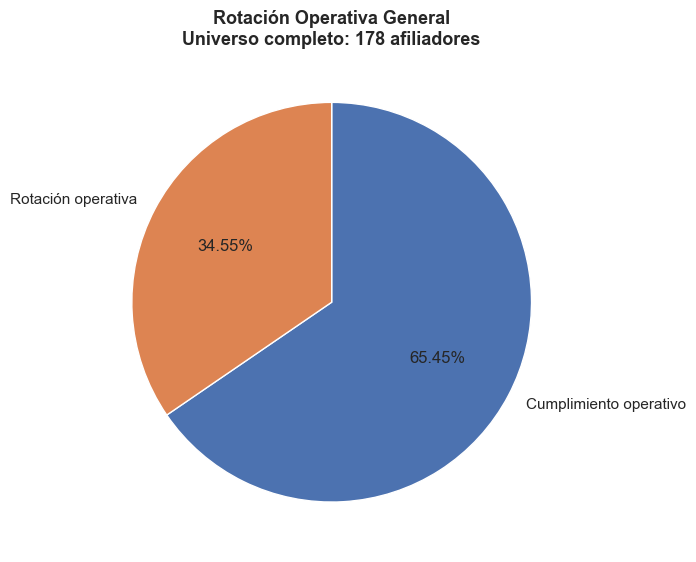

In [29]:
# =========================================================
# GRÁFICO 1: UNIVERSO COMPLETO
# =========================================================

import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

# Datos universo completo
afiliadores_evaluados = 178
cumplimiento_pct = 65.45
rotacion_pct = 34.55

labels = ["Cumplimiento operativo", "Rotación operativa"]
values = [cumplimiento_pct, rotacion_pct]

plt.figure(figsize=(7, 7))

plt.pie(
    values,
    labels=labels,
    autopct="%1.2f%%",
    startangle=90,
    counterclock=False,
    wedgeprops={"edgecolor": "white"}
)

plt.title(
    f"Rotación Operativa General\nUniverso completo: {afiliadores_evaluados} afiliadores",
    fontsize=13,
    fontweight="bold"
)

plt.tight_layout()
plt.show()

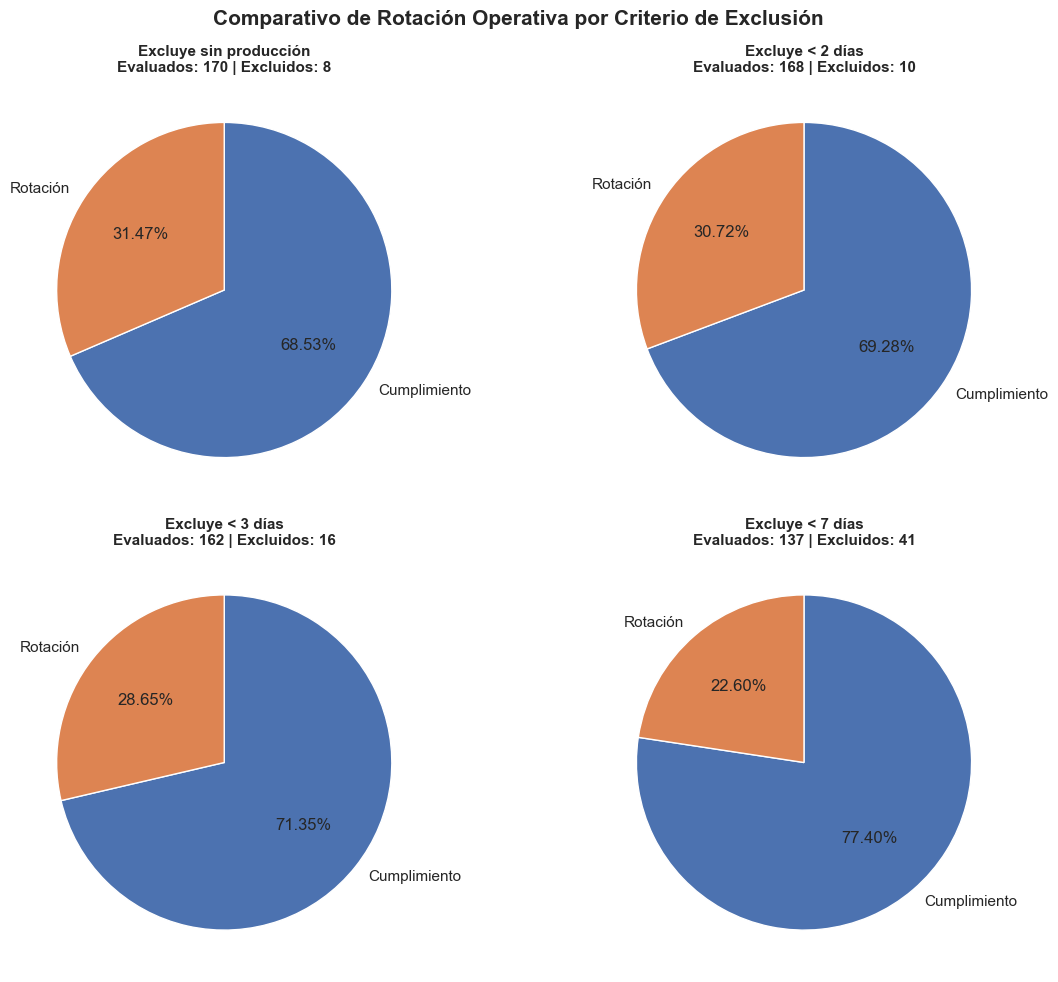

In [30]:
# =========================================================
# GRÁFICO 2: COMPARATIVO DE ESCENARIOS DEPURADOS
# =========================================================

import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

escenarios = [
    {
        "titulo": "Excluye sin producción",
        "evaluados": 170,
        "excluidos": 8,
        "cumplimiento": 68.53,
        "rotacion": 31.47
    },
    {
        "titulo": "Excluye < 2 días",
        "evaluados": 168,
        "excluidos": 10,
        "cumplimiento": 69.28,
        "rotacion": 30.72
    },
    {
        "titulo": "Excluye < 3 días",
        "evaluados": 162,
        "excluidos": 16,
        "cumplimiento": 71.35,
        "rotacion": 28.65
    },
    {
        "titulo": "Excluye < 7 días",
        "evaluados": 137,
        "excluidos": 41,
        "cumplimiento": 77.40,
        "rotacion": 22.60
    }
]

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()

for ax, escenario in zip(axes, escenarios):
    values = [
        escenario["cumplimiento"],
        escenario["rotacion"]
    ]

    labels = [
        "Cumplimiento",
        "Rotación"
    ]

    ax.pie(
        values,
        labels=labels,
        autopct="%1.2f%%",
        startangle=90,
        counterclock=False,
        wedgeprops={"edgecolor": "white"}
    )

    ax.set_title(
        f"{escenario['titulo']}\n"
        f"Evaluados: {escenario['evaluados']} | Excluidos: {escenario['excluidos']}",
        fontsize=11,
        fontweight="bold"
    )

plt.suptitle(
    "Comparativo de Rotación Operativa por Criterio de Exclusión",
    fontsize=15,
    fontweight="bold"
)

plt.tight_layout()
plt.show()